# Reducing the Dimensionality of Data with Neural Networks
**Authors:** G. E. Hinton, R. R. Salakhutdinov (University of Toronto)
**Published:** Science, Vol. 313, 28 July 2006

# https://www.cs.toronto.edu/~hinton/absps/science.pdf

## Abstract
The paper introduces a method for nonlinear dimensionality reduction using deep, multilayer "autoencoder" neural networks. High-dimensional data can be converted into low-dimensional codes by training a network with a small central (bottleneck) layer to reconstruct the original high-dimensional input. While gradient descent can fine-tune such networks, it only succeeds when the initial weights are already close to a good solution. The authors propose a layer-by-layer pretraining procedure, based on Restricted Boltzmann Machines (RBMs), that produces such favorable initial weights, enabling deep autoencoders to learn low-dimensional codes that substantially outperform Principal Components Analysis (PCA).

## Problems
- **Optimization difficulty in deep nonlinear autoencoders:** Networks with multiple hidden layers are hard to train with standard backpropagation.
- **Weight initialization sensitivity:**
  - Large initial weights lead gradient descent to poor local minima.
  - Small initial weights cause vanishing gradients in early layers, making training infeasible for many-layered networks.
- **Limitations of linear dimensionality reduction:** PCA can only capture linear structure and performs poorly when the true underlying relationship between high-dimensional inputs and low-dimensional codes is highly nonlinear.

## Proposed Solutions
- A **greedy, layer-by-layer pretraining algorithm** using stacks of RBMs, each modeling one layer of binary (or real-valued) stochastic feature detectors.
- Pretrained RBMs are **"unrolled"** into a symmetric encoder–decoder architecture (the autoencoder), using the RBM weights as initialization.
- The unrolled network is then **fine-tuned globally** with backpropagation, replacing stochastic activations with deterministic real-valued probabilities, to minimize reconstruction error.
- Extension of the pretraining procedure from binary data to **real-valued data**, using linear visible units with Gaussian noise for the first-layer RBM.

## Purpose
To demonstrate that deep autoencoders, when properly initialized via unsupervised layer-wise pretraining, can learn compact, nonlinear, low-dimensional representations of data that are more faithful (lower reconstruction error) than those obtained by PCA or other linear methods, across diverse data types (images, digits, faces, documents).

## Methodology

### Model Architecture
- **RBM formulation:** Visible units $v_i$ and hidden units $h_j$ with an energy function:
$$
E(v, h) = -\sum_{i \in \text{pixels}} b_i v_i - \sum_{j \in \text{features}} b_j h_j - \sum_{i,j} v_i h_j w_{ij}
$$
- **Hidden unit activation probability:**
$$
P(h_j = 1 \mid v) = \sigma\left(b_j + \sum_i v_i w_{ij}\right)
$$
- **Visible unit reconstruction probability:**
$$
P(v_i = 1 \mid h) = \sigma\left(b_i + \sum_j h_j w_{ij}\right)
$$
- **Contrastive Divergence weight update rule:**
$$
\Delta w_{ij} = \varepsilon \left( \langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{recon}} \right)
$$

### Pretraining Procedure
1. Train an RBM on the raw data to learn a first layer of feature detectors.
2. Use the activation probabilities of the first RBM as "data" to train a second RBM, and repeat for additional layers.
3. Each additional RBM layer provably improves a lower bound on the log-probability of the training data (given non-decreasing layer sizes and correct initialization).

### Unrolling and Fine-Tuning
- After pretraining, the stack of RBMs is unrolled into an encoder network (compressing to a code layer) and a symmetric decoder network (reconstructing the input), sharing initial weights.
- Fine-tuning uses backpropagation of reconstruction error through the entire autoencoder (encoder + decoder).
- For binary/bounded data, cross-entropy reconstruction error is minimized:
$$
-\sum_i p_i \log \hat{p}_i - \sum_i (1-p_i)\log(1-\hat{p}_i)
$$

### Datasets and Architectures Tested
| Dataset | Architecture | Notes |
|---|---|---|
| Synthetic curves | $(28\times28)$-400-200-100-50-25-6 | 20,000 training / 10,000 test images |
| MNIST handwritten digits | 784-1000-500-250-30 (and 784-1000-500-250-2 for visualization) | 60,000 training / 10,000 test images |
| Olivetti face patches | 625-2000-1000-500-30 | Grayscale image patches |
| Reuters newswire documents | 2000-500-250-125-10 (and 125-2 variant) | 804,414 documents, 2000 commonest word stems |

## Results
- **Curve dataset:** The six-dimensional deep autoencoder achieved substantially lower average squared reconstruction error (1.44) compared to logistic PCA (7.64) and standard PCA (5.90 with 18 components).
- **MNIST digits:** The 30-dimensional autoencoder produced markedly better reconstructions than 30-dimensional logistic PCA and standard PCA (average squared errors of 3.00 vs. 8.01 and 13.87, respectively). A two-dimensional autoencoder code also produced clearer class separation in visualization than the first two principal components.
- **Face images:** The 30-dimensional autoencoder outperformed PCA, with average squared errors of 126 vs. 135.
- **Document retrieval:** Using a 2000-500-250-125-10 autoencoder on Reuters newswire data, cosine similarity between 10-dimensional codes outperformed Latent Semantic Analysis (LSA) in retrieval accuracy across varying numbers of retrieved documents; autoencoders also outperformed local linear embedding.
- **Classification:** On MNIST digit classification, a pretrained 784-500-500-2000-10 network fine-tuned with backpropagation achieved a 1.2% error rate, improving on 1.6% for randomly initialized backpropagation and 1.4% for support vector machines.
- **Without pretraining:** Very deep autoencoders failed to learn useful representations, collapsing to reconstructing the average of the training data even after prolonged fine-tuning.

## Conclusions
- Layer-by-layer pretraining using RBMs provides an effective initialization strategy that overcomes the optimization difficulties of training deep nonlinear autoencoders via gradient descent.
- Deep autoencoders trained with this pretraining-then-fine-tuning approach consistently outperform PCA and other linear or shallow nonlinear methods (logistic PCA, LSA, local linear embedding) for dimensionality reduction across image, digit, face, and text domains.
- The approach scales to large datasets since both pretraining and fine-tuning have time and space complexity that scale linearly with the number of training cases.
- Unlike nonparametric dimensionality reduction techniques, autoencoders learn explicit, bidirectional mappings between the high-dimensional data space and the low-dimensional code space, enabling both compression and reconstruction.
- The work establishes pretraining as a foundational technique that made deep network training feasible, contributing significantly to the subsequent resurgence of deep learning research.

# Mathematical and Statistical Content
## "Reducing the Dimensionality of Data with Neural Networks" (Hinton & Salakhutdinov, 2006)

## 1. Energy Function of a Restricted Boltzmann Machine (RBM)

$$
E(v, h) = -\sum_{i \in \text{pixels}} b_i v_i - \sum_{j \in \text{features}} b_j h_j - \sum_{i,j} v_i h_j w_{ij}
$$

**Explanation:** This defines a scalar "energy" for any joint configuration of visible units $v$ (e.g., pixel values) and hidden units $h$ (feature detectors). Lower energy corresponds to more probable configurations. The terms represent: bias contributions from visible units, bias contributions from hidden units, and pairwise interaction terms weighted by $w_{ij}$, the connection strength between pixel $i$ and feature $j$. This energy function is the basis for defining a probability distribution over all possible images (via a Boltzmann/Gibbs distribution, not explicitly written but referenced in the text).

## 2. Hidden Unit Activation Probability

$$
P(h_j = 1 \mid v) = \sigma\left(b_j + \sum_i v_i w_{ij}\right), \quad \sigma(x) = \frac{1}{1 + e^{-x}}
$$

**Explanation:** Given a visible configuration (an image), each hidden unit (feature detector) turns "on" (binary state 1) with a probability determined by passing a weighted sum of the visible units through the logistic sigmoid function $\sigma(x)$. This describes how the network infers feature activations from data — a form of stochastic binary classification per unit.

## 3. Visible Unit Reconstruction Probability ("Confabulation")

$$
P(v_i = 1 \mid h) = \sigma\left(b_i + \sum_j h_j w_{ij}\right)
$$

**Explanation:** Symmetric to the hidden unit rule, this gives the probability of reconstructing (regenerating) each pixel from the current hidden feature activations. Sampling from this distribution produces a "confabulation" — a fantasy image the model generates from its own learned features, used for learning.

## 4. Contrastive Divergence Weight Update Rule

$$
\Delta w_{ij} = \varepsilon\left(\langle v_i h_j \rangle_{\text{data}} - \langle v_i h_j \rangle_{\text{recon}}\right)
$$

**Explanation:** This is the learning rule for training the RBM. $\varepsilon$ is the learning rate. $\langle v_i h_j \rangle_{\text{data}}$ is the average co-occurrence frequency of pixel $i$ and feature $j$ being simultaneously active when the network is driven by real training data. $\langle v_i h_j \rangle_{\text{recon}}$ is the same statistic but computed on the model's reconstructed ("confabulated") data. The weight is adjusted to increase the former and decrease the latter — effectively pushing the model to assign higher probability to real data and lower probability to its own generated samples. This is a simplified, computationally efficient approximation to true maximum-likelihood gradient ascent (it does not follow the exact gradient of the log-likelihood, but works well in practice).

A matching, simplified version of this same rule is applied to update the bias terms $b_i$ and $b_j$.

## 5. Gaussian (Real-Valued) Visible Units

For continuous-valued data, the first-layer RBM's visible units are modeled as linear units with added Gaussian noise instead of binary units. With unit variance, the update rule becomes:

**Explanation:** Instead of sampling a binary pixel state, each visible unit is sampled from a Gaussian (normal) distribution centered at $b_i + \sum_j h_j w_{ij}$ with unit variance. This generalizes the binary RBM formulation to handle continuous data (such as grayscale pixel intensities or document term probabilities), while the hidden units remain binary/stochastic.

## 6. Cross-Entropy Reconstruction Error (Fine-Tuning Objective)

For binary/probability-valued data:

$$
-\sum_i p_i \log \hat{p}_i - \sum_i (1-p_i)\log(1-\hat{p}_i)
$$

**Explanation:** This is the loss function minimized during the global fine-tuning (backpropagation) stage. $p_i$ is the true intensity/probability of pixel (or feature) $i$, and $\hat{p}_i$ is the network's reconstructed estimate. Cross-entropy penalizes the network more heavily as its reconstructed probability diverges from the true value, and is the natural loss function when treating pixel intensities as probabilities of a binary event.

**Multiclass variant** (used for document/word-stem data):

$$
-\sum_i p_i \log \hat{p}_i
$$

**Explanation:** A categorical (multiclass) cross-entropy, appropriate when $p_i$ represents a distribution over discrete outcomes (e.g., word-stem probabilities in a document) rather than independent binary pixels.

## 7. Average Squared Reconstruction Error (Evaluation Metric)

**Explanation:** Although not given as a single formula in the text, this metric — the mean of the squared differences between original inputs and their reconstructions — is used throughout the Results (e.g., Fig. 2, Fig. 3) to quantitatively compare the autoencoder's performance against PCA and logistic PCA. Lower average squared error indicates a more faithful, information-preserving low-dimensional code.

## 8. Principal Components Analysis (PCA) — Conceptual/Statistical Baseline

**Explanation:** PCA is referenced as the standard linear baseline method. It finds orthogonal directions of maximum variance in the data and projects each data point onto its coordinates along these directions. It is a purely linear technique (equivalent to a single-layer linear autoencoder), which is why it is outperformed by the nonlinear, deep autoencoder on data with nonlinear underlying structure.

## 9. Cosine Similarity (Document Retrieval Metric)

**Explanation:** Used to measure similarity between the 10-dimensional document codes for retrieval evaluation (Fig. 4). The cosine of the angle between two code vectors quantifies how similar two documents are in the learned low-dimensional space — a standard statistical similarity measure for high-dimensional or embedded vector representations, here applied to compare autoencoder codes against Latent Semantic Analysis (LSA) codes.

## Summary Table

| Concept | Role in Paper |
|---|---|
| RBM energy function | Defines probability model over data/feature configurations |
| Sigmoid activation rules | Stochastic inference of hidden/visible unit states |
| Contrastive divergence update | Efficient approximate learning rule for RBM weights |
| Gaussian visible units | Extends RBMs to continuous-valued data |
| Cross-entropy loss | Objective minimized during backpropagation fine-tuning |
| Squared reconstruction error | Metric to compare autoencoder vs. PCA performance |
| PCA | Linear baseline for dimensionality reduction |
| Cosine similarity | Metric for evaluating document retrieval quality |

# Problems, Limitations, and Proposed Solutions
## "Reducing the Dimensionality of Data with Neural Networks" (Hinton & Salakhutdinov, 2006)

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Nonlinear autoencoders with multiple hidden layers are difficult to optimize via standard gradient descent. | Prior nonlinear dimensionality-reduction attempts using deep networks failed to train reliably, restricting practical use to shallow or linear models. | Introduce a layer-by-layer unsupervised pretraining procedure using stacked Restricted Boltzmann Machines (RBMs) to find good initial weights before applying gradient-based fine-tuning. |
| 2 | Large random initial weights cause deep autoencoders to settle into poor local minima. | Random initialization strategies used in earlier backpropagation-based approaches produced suboptimal, hard-to-escape solutions in deep architectures. | Pretrain each layer greedily as an RBM so that weights start close to a good region of the solution space before global fine-tuning. |
| 3 | Small initial weights cause vanishing gradients in early layers of deep networks. | Made it infeasible to effectively train autoencoders with many hidden layers using gradient descent alone, limiting achievable network depth. | Use RBM-based pretraining, which learns useful low-level and high-level features layer by layer without relying on backpropagated gradients through the full depth of the network. |
| 4 | PCA and other linear dimensionality-reduction methods cannot capture nonlinear structure in high-dimensional data. | Linear techniques yield high reconstruction error and poor low-dimensional representations when the true data manifold is nonlinear (e.g., natural images, digit shapes, documents). | Replace linear projection with a nonlinear, multilayer "encoder" network trained to output compact codes that a symmetric "decoder" network can reconstruct with minimal error. |
| 5 | RBM-based pretraining, as originally formulated, applies primarily to binary data. | Restricted applicability of the pretraining approach to datasets with continuous or probability-valued features (e.g., grayscale images, document word-frequency vectors). | Generalize the first-layer RBM to use linear visible units with Gaussian noise, enabling pretraining on real-valued data while keeping hidden units stochastic and binary. |
| 6 | No prior systematic comparison demonstrating deep autoencoders outperforming PCA/logistic PCA/LSA across diverse data types. | Left open whether nonlinear autoencoders provide practical improvements over well-established linear methods for real-world dimensionality-reduction tasks. | Empirically evaluate the pretrained deep autoencoder against PCA, logistic PCA, and LSA on curves, MNIST digits, face images, and newswire documents, demonstrating consistently lower reconstruction error and improved retrieval/classification performance. |
| 7 | Efficient scaling of nonlinear dimensionality-reduction methods to very large datasets was unproven. | Nonparametric nonlinear methods (e.g., local linear embedding) do not scale well and lack an explicit mapping between data and code spaces. | Show that both the pretraining and fine-tuning stages scale linearly in time and space with the number of training cases, and that the autoencoder provides explicit bidirectional (encoder/decoder) mappings, unlike nonparametric alternatives. |

In [1]:
# !pip -q install datasets scikit-learn

# =====================================================================================
# Educational PyTorch Replication:
# "Reducing the Dimensionality of Data with Neural Networks" (Hinton & Salakhutdinov, 2006)
# Adapted to CIFAR-10 for illustration. This is NOT the original curve/MNIST/face/document
# experiment -- it is a simplified, faithful-in-spirit reproduction of the CORE METHOD:
#   Stage 1: Greedy layer-by-layer pretraining of Restricted Boltzmann Machines (RBMs).
#   Stage 2: Unroll the pretrained RBM stack into a symmetric deep autoencoder and
#            fine-tune the whole encoder-decoder with backpropagation.
#
# WHAT IS DIMENSIONALITY REDUCTION?
#   We want to describe a high-dimensional input (here, a flattened small RGB image)
#   using far fewer numbers (a "code"), while still being able to approximately
#   reconstruct the original input from that code.
#
# WHAT IS AN AUTOENCODER?
#   A neural network with two halves: an ENCODER that compresses the input into a
#   small CODE LAYER (bottleneck), and a DECODER that tries to reconstruct the
#   original input from that code. Training minimizes reconstruction error.
#
# WHY IS THE CODE LAYER LINEAR?
#   A linear code layer lets the network output any real value (not squashed into
#   [0,1] by a sigmoid), so it can behave like a nonlinear analogue of PCA components.
#
# WHY ARE DEEP AUTOENCODERS HARD TO TRAIN FROM RANDOM WEIGHTS?
#   With large random weights, gradient descent tends to get stuck in poor local
#   minima. With small random weights, gradients shrink as they are backpropagated
#   through many layers ("vanishing gradients"), so early layers barely learn.
#
# WHAT IS UNSUPERVISED PRETRAINING / AN RBM?
#   Before fine-tuning the whole deep network, we train each layer separately as a
#   Restricted Boltzmann Machine (RBM): a small two-layer, undirected, stochastic
#   network that learns to model the statistics of its input without any labels.
#   Each RBM's hidden-activation probabilities become the "data" for training the
#   next RBM above it (layer-by-layer, or "greedy", pretraining).
#
# WHAT IS CONTRASTIVE DIVERGENCE (CD)?
#   An efficient, approximate learning rule for RBMs. It nudges weights so that the
#   energy of real data goes down and the energy of the model's own one-step
#   reconstructions ("confabulations") goes up, without needing the exact (expensive)
#   gradient of the log-likelihood.
#
# WHAT IS "UNROLLING"?
#   After all RBMs are pretrained, we stack the encoder RBMs and mirror them with a
#   decoder that starts from the SAME (transposed) weights. This gives the deep
#   autoencoder a much better starting point than random initialization.
#
# WHY ARE ENCODER/DECODER UNTIED AFTER UNROLLING?
#   The paper only ties the weights as an INITIALIZATION. During fine-tuning, encoder
#   and decoder parameters are allowed to diverge independently via backpropagation,
#   since nothing forces them to stay identical (unlike the RBM's original weight-tying).
#
# WHY IS BACKPROPAGATION ONLY USED AFTER PRETRAINING?
#   Pretraining uses a different, layer-local, gradient-free (manual CD) learning
#   rule. Backpropagation is used only in the final global fine-tuning stage, once
#   the whole network is unrolled into a single differentiable computation graph.
#
# WHY IS RECONSTRUCTION THE TRAINING OBJECTIVE, AND WHY NO LABELS?
#   The whole point of this method is UNSUPERVISED dimensionality reduction: the
#   network should learn a compact code purely by trying to reconstruct its own
#   input. Labels are only used AFTER training, to diagnose how good the codes are.
#
# WHY COMPARE WITH PCA?
#   PCA is the classical LINEAR dimensionality-reduction baseline the paper compares
#   against. The autoencoder is a NONLINEAR generalization of PCA: PCA finds a single
#   linear projection, while the autoencoder can learn curved, nonlinear manifolds.
#
# WHY IS A "FROZEN LINEAR PROBE" ONLY A DIAGNOSTIC, NOT PART OF TRAINING?
#   We freeze the autoencoder (no further learning) and train a small separate
#   linear classifier on top of its codes just to measure how much class information
#   the UNSUPERVISED codes happen to capture. The autoencoder itself never sees labels.
#
# HOW DOES THIS DIFFER FROM A VARIATIONAL AUTOENCODER (VAE)?
#   A VAE optimizes a probabilistic lower bound with an explicit KL-divergence
#   regularizer pushing the code distribution toward a prior (e.g. a Gaussian). This
#   paper's autoencoder has no such regularizer -- it is a deterministic
#   encoder-decoder trained purely to minimize reconstruction error, with RBM-based
#   pretraining, not VAE-style variational inference.
#
# HOW DOES THIS RELATE TO DEEP BELIEF NETWORKS (DBNs)?
#   The RBM-stacking pretraining procedure is the same idea introduced for Deep
#   Belief Networks (Hinton, Osindero & Teh, 2006). This paper reuses that greedy
#   layer-wise pretraining but unrolls the stack into an autoencoder for
#   reconstruction rather than keeping it as a generative belief network.
#
# WHY IS THIS CIFAR-10 ADAPTATION LESS FAITHFUL THAN THE ORIGINAL PAPER?
#   The original paper used binary/near-binary MNIST digits, synthetic 2D-generated
#   curves, grayscale face patches, and bag-of-words document vectors -- all much
#   lower-noise and often naturally close to binary. CIFAR-10 natural RGB images are
#   noisier, more continuous, and only mildly compressed by average pooling here, so
#   this replication is a simplified educational analogue, not a strict reproduction.
# =====================================================================================

import os
import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset

import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

from PIL import Image
from IPython.display import display, Image as IPImage

from datasets import load_dataset

In [2]:
# --------------------------------------------------------------------------------------
# REPRODUCIBILITY
# --------------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# --------------------------------------------------------------------------------------
# WHITE VISUAL THEME (enforced globally, and again before the final dashboard)
# --------------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.edgecolor": "black",
        "legend.facecolor": "white",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "axes.grid": True,
        "grid.alpha": 0.6,
    })

set_white_theme()

In [4]:
# --------------------------------------------------------------------------------------
# INPUT REPRESENTATION CONSTANTS
# --------------------------------------------------------------------------------------
IMG_SIZE = 64
POOL_SIZE = 16
INPUT_DIM = 3 * POOL_SIZE * POOL_SIZE  # 768, continuous values in [0, 1]

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

In [ ]:
# --------------------------------------------------------------------------------------
# DATASET -- HUGGINGFACE CIFAR-10 ONLY
# --------------------------------------------------------------------------------------
print("Loading CIFAR-10 from HuggingFace datasets ...")
ds = load_dataset("uoft-cs/cifar10")

In [6]:
# --------------------------------------------------------------------------------------
# TRANSFORMS
# --------------------------------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN.flatten().tolist(),
                          std=IMAGENET_STD.flatten().tolist()),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN.flatten().tolist(),
                          std=IMAGENET_STD.flatten().tolist()),
])


class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label


full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

In [7]:
# --------------------------------------------------------------------------------------
# SUBSETS AND DATA LOADERS
# --------------------------------------------------------------------------------------
N_TRAIN = 2000
N_TEST = 400

train_subset = Subset(full_train_dataset, list(range(N_TRAIN)))
test_subset = Subset(full_test_dataset, list(range(N_TEST)))

PIN_MEMORY = torch.cuda.is_available()

train_loader_raw = DataLoader(train_subset, batch_size=64, shuffle=True,
                               num_workers=2, pin_memory=PIN_MEMORY)
test_loader_raw = DataLoader(test_subset, batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=PIN_MEMORY)

In [8]:
# --------------------------------------------------------------------------------------
# (cont.) PREPROCESSING: undo ImageNet norm -> clamp [0,1] -> pool to 16x16 -> flatten
# --------------------------------------------------------------------------------------
def preprocess_batch(img_batch):
    """
    Natural-image pixel intensities are continuous, not naturally binary, so we
    preprocess CIFAR-10 into continuous [0,1] values and treat the bottom RBM as a
    Gaussian-visible / Bernoulli-hidden EDUCATIONAL approximation of the paper's
    real-valued extension (Sec. "For continuous data...").
    """
    mean = IMAGENET_MEAN.to(img_batch.device)
    std = IMAGENET_STD.to(img_batch.device)
    unnorm = img_batch * std + mean          # undo ImageNet normalization
    unnorm = torch.clamp(unnorm, 0.0, 1.0)   # clamp RGB to [0, 1]
    pooled = F.adaptive_avg_pool2d(unnorm, (POOL_SIZE, POOL_SIZE))  # -> 16x16, all 3 channels
    flat = pooled.view(pooled.size(0), -1)   # flatten to 768
    return flat, pooled

In [9]:
# --------------------------------------------------------------------------------------
# DATA SANITY CHECK
# --------------------------------------------------------------------------------------
sample_imgs, sample_labels = next(iter(train_loader_raw))
sample_flat, sample_pooled = preprocess_batch(sample_imgs)

print("=== DATA SANITY CHECK ===")
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Original image-batch shape:", tuple(sample_imgs.shape))
print("Pooled RGB shape:", tuple(sample_pooled.shape))
print("Flattened autoencoder-input shape:", tuple(sample_flat.shape))
print("Input-value range: [%.4f, %.4f]" % (sample_flat.min().item(), sample_flat.max().item()))
print("Label range: [%d, %d]" % (sample_labels.min().item(), sample_labels.max().item()))
print("First eight integer labels:", sample_labels[:8].tolist())
print("First eight class names:", [CLASS_NAMES[l] for l in sample_labels[:8].tolist()])

assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert sample_flat.min().item() >= -1e-4 and sample_flat.max().item() <= 1.0 + 1e-4
assert torch.isfinite(sample_flat).all()

=== DATA SANITY CHECK ===
Number of training samples: 2000
Number of test samples: 400
Original image-batch shape: (64, 3, 64, 64)
Pooled RGB shape: (64, 3, 16, 16)
Flattened autoencoder-input shape: (64, 768)
Input-value range: [0.0034, 1.0000]
Label range: [0, 9]
First eight integer labels: [4, 1, 6, 4, 7, 3, 4, 8]
First eight class names: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [10]:
# =====================================================================================
# RBM BASE CLASS
# =====================================================================================
class RBMBase:
    """
    Reusable Restricted Boltzmann Machine base class.

    An RBM has a "visible" layer (input) and a "hidden" layer (feature detectors),
    connected by a weight matrix W. There are NO connections within a layer
    ("restricted"), which makes inference in one direction fast and exact given
    the other layer's state.

    Energy function (from the paper):
        E(v, h) = - sum_i b_i * v_i - sum_j c_j * h_j - sum_{i,j} v_i * h_j * W_ij
    Lower energy => higher probability under the model.
    """

    def __init__(self, n_visible, n_hidden, rbm_type, device=DEVICE):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.rbm_type = rbm_type  # "gaussian_bernoulli", "bernoulli_bernoulli", "bernoulli_gaussian"
        self.device = device

        # Small random weight init (paper: weights initialized randomly before pretraining)
        self.W = (torch.randn(n_visible, n_hidden, device=device) * 0.01)
        self.v_bias = torch.zeros(n_visible, device=device)
        self.h_bias = torch.zeros(n_hidden, device=device)

        # Momentum buffers for manual updates
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_v_bias = torch.zeros_like(self.v_bias)
        self.velocity_h_bias = torch.zeros_like(self.h_bias)

        self.sigma = 1.0  # fixed unit variance for Gaussian units (paper's simplification)

    # ---------------- Hidden inference ----------------
    def hidden_mean(self, v):
        if self.rbm_type in ("gaussian_bernoulli", "bernoulli_bernoulli"):
            # p(h_j=1|v) = sigmoid(c_j + sum_i v_i W_ij / sigma^2)
            pre_act = self.h_bias + (v @ self.W) / (self.sigma ** 2)
            return torch.sigmoid(pre_act)
        elif self.rbm_type == "bernoulli_gaussian":
            # continuous top code: mean = v @ W + c  (linear, Gaussian hidden units)
            return self.h_bias + (v @ self.W)
        else:
            raise ValueError(self.rbm_type)

    def sample_hidden(self, v, sample_gaussian_code=False):
        mean = self.hidden_mean(v)
        if self.rbm_type in ("gaussian_bernoulli", "bernoulli_bernoulli"):
            sample = torch.bernoulli(mean)
            return mean, sample
        else:  # bernoulli_gaussian (continuous code layer)
            if sample_gaussian_code:
                noise = torch.randn_like(mean)
                sample = mean + noise
            else:
                sample = mean.clone()
            return mean, sample

    # ---------------- Visible inference (reconstruction / "confabulation") ----------------
    def visible_mean(self, h):
        if self.rbm_type == "gaussian_bernoulli":
            # continuous visible mean: b_i + sum_j h_j W_ij
            return self.v_bias + (h @ self.W.t())
        elif self.rbm_type in ("bernoulli_bernoulli", "bernoulli_gaussian"):
            pre_act = self.v_bias + (h @ self.W.t())
            return torch.sigmoid(pre_act)
        else:
            raise ValueError(self.rbm_type)

    def sample_visible(self, h, sample_gaussian_visible=False):
        mean = self.visible_mean(h)
        if self.rbm_type == "gaussian_bernoulli":
            if sample_gaussian_visible:
                noise = torch.randn_like(mean) * self.sigma
                sample = mean + noise
            else:
                sample = mean.clone()
            sample = torch.clamp(sample, 0.0, 1.0)  # clamp for stability / display
            return mean, sample
        else:
            sample = torch.bernoulli(mean)
            return mean, sample

    # ---------------- Energy ----------------
    def compute_energy(self, v, h):
        term_v = (self.v_bias * v).sum(dim=1)
        term_h = (self.h_bias * h).sum(dim=1)
        term_vh = ((v @ self.W) * h).sum(dim=1)
        return -(term_v + term_h + term_vh)

    def compute_free_energy(self, v):
        """Free energy: -sum log(1+exp(pre_act)) - v.b term (Bernoulli-hidden case),
        approximated similarly for Gaussian-hidden top RBM using the linear pre-activation."""
        vbias_term = v @ self.v_bias
        wx_b = self.h_bias + (v @ self.W) / (self.sigma ** 2)
        if self.rbm_type in ("gaussian_bernoulli", "bernoulli_bernoulli"):
            hidden_term = torch.log1p(torch.exp(torch.clamp(wx_b, -30, 30))).sum(dim=1)
        else:
            # Gaussian hidden units: free energy contribution ~ 0.5 * pre_act^2 (up to constants)
            hidden_term = 0.5 * (wx_b ** 2).sum(dim=1)
        return -(vbias_term + hidden_term)

    # ---------------- Reconstruction ----------------
    def reconstruct(self, v, k=1, sample_gaussian_visible=False, sample_gaussian_code=False):
        v_state = v
        for _ in range(k):
            h_mean, h_sample = self.sample_hidden(v_state, sample_gaussian_code=sample_gaussian_code)
            v_mean, v_sample = self.sample_visible(h_sample, sample_gaussian_visible=sample_gaussian_visible)
            v_state = v_sample
        return v_mean, v_state

    # ---------------- Contrastive Divergence (CD-k) ----------------
    def contrastive_divergence(self, v_data, k=1,
                                sample_gaussian_visible=False, sample_gaussian_code=False):
        """
        CD-k contrasts data-driven statistics against one-step (or k-step)
        reconstruction statistics. This is NOT the exact gradient of the
        log-likelihood, but a fast, effective approximation (Hinton, 2002).
        """
        batch_size = v_data.size(0)

        # Positive phase (data-driven)
        h_prob_data, h_sample_data = self.sample_hidden(v_data, sample_gaussian_code=sample_gaussian_code)
        positive_association = (v_data.t() @ h_prob_data) / batch_size

        # Negative phase (model-driven, k steps of Gibbs sampling)
        v_state = v_data
        h_sample = h_sample_data
        for _ in range(k):
            v_mean, v_recon = self.sample_visible(h_sample, sample_gaussian_visible=sample_gaussian_visible)
            h_prob_recon, h_sample = self.sample_hidden(v_recon, sample_gaussian_code=sample_gaussian_code)
            v_state = v_recon

        negative_association = (v_state.t() @ h_prob_recon) / batch_size

        weight_direction = positive_association - negative_association
        visible_bias_direction = (v_data - v_state).mean(dim=0)
        hidden_bias_direction = (h_prob_data - h_prob_recon).mean(dim=0)

        stats = {
            "positive_association": positive_association.abs().mean().item(),
            "negative_association": negative_association.abs().mean().item(),
            "association_contrast": weight_direction.abs().mean().item(),
            "h_prob_data": h_prob_data,
            "v_recon_mean": v_mean,
        }
        return weight_direction, visible_bias_direction, hidden_bias_direction, stats

    # ---------------- Manual parameter update (no autograd, no optim) ----------------
    def manual_parameter_update(self, weight_direction, visible_bias_direction,
                                 hidden_bias_direction, lr, momentum, weight_decay):
        with torch.no_grad():
            self.velocity_W = momentum * self.velocity_W + lr * (weight_direction - weight_decay * self.W)
            self.velocity_v_bias = momentum * self.velocity_v_bias + lr * visible_bias_direction
            self.velocity_h_bias = momentum * self.velocity_h_bias + lr * hidden_bias_direction

            self.W += self.velocity_W
            self.v_bias += self.velocity_v_bias
            self.h_bias += self.velocity_h_bias

            w_update_norm = self.velocity_W.norm().item()
            vb_update_norm = self.velocity_v_bias.norm().item()
            hb_update_norm = self.velocity_h_bias.norm().item()
        return w_update_norm, vb_update_norm, hb_update_norm

In [11]:
# --------------------------------------------------------------------------------------
# RBM PRETRAINING HYPERPARAMETERS
# --------------------------------------------------------------------------------------
PRETRAIN_EPOCHS = 5
CD_K = 1
RBM_LEARNING_RATE = 0.05
INITIAL_MOMENTUM = 0.5
FINAL_MOMENTUM = 0.9
RBM_WEIGHT_DECAY = 1e-4

SAMPLE_GAUSSIAN_VISIBLE = False  # RBM1: use conditional mean directly in CD stats (stability)
SAMPLE_GAUSSIAN_CODE = True      # RBM4: add unit-variance Gaussian noise to top code during pretraining


def momentum_for_epoch(epoch_idx):
    # Epochs 1,2 -> 0.5 ; Epochs 3,4,5 -> 0.9
    return INITIAL_MOMENTUM if epoch_idx < 2 else FINAL_MOMENTUM


# --------------------------------------------------------------------------------------
# Helper: build flattened [0,1] representation datasets/loaders from raw image loaders
# --------------------------------------------------------------------------------------
def build_flat_dataset(loader):
    all_flat = []
    all_labels = []
    for imgs, labels in loader:
        flat, _ = preprocess_batch(imgs)
        all_flat.append(flat)
        all_labels.append(labels)
    all_flat = torch.cat(all_flat, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    return all_flat, all_labels


print("\nPreprocessing full train/test subsets into flattened [0,1] 768-dim vectors ...")
train_flat_all, train_labels_all = build_flat_dataset(train_loader_raw)
test_flat_all, test_labels_all = build_flat_dataset(test_loader_raw)
print("train_flat_all:", tuple(train_flat_all.shape), " test_flat_all:", tuple(test_flat_all.shape))


def make_loader_from_tensor(x, batch_size=64, shuffle=True):
    ds_ = TensorDataset(x)
    return DataLoader(ds_, batch_size=batch_size, shuffle=shuffle, num_workers=0)


Preprocessing full train/test subsets into flattened [0,1] 768-dim vectors ...
train_flat_all: (2000, 768)  test_flat_all: (400, 768)


In [12]:
# =====================================================================================
# GREEDY RBM PRETRAINING STACK
# =====================================================================================
pretrain_metrics = {
    "rbm1": {"bce": [], "mse": [], "assoc_contrast": [], "w_update_norm": [],
             "free_energy_gap": [], "hidden_sparsity": []},
    "rbm2": {"bce": [], "mse": [], "assoc_contrast": [], "w_update_norm": [],
             "free_energy_gap": [], "hidden_sparsity": []},
    "rbm3": {"bce": [], "mse": [], "assoc_contrast": [], "w_update_norm": [],
             "free_energy_gap": [], "hidden_sparsity": []},
    "rbm4": {"bce": [], "mse": [], "assoc_contrast": [], "w_update_norm": [],
             "code_mean": [], "code_std": []},
}


def bce_safe(pred, target):
    pred = torch.clamp(pred, 1e-6, 1 - 1e-6)
    return F.binary_cross_entropy(pred, torch.clamp(target, 0.0, 1.0)).item()


def mse_safe(pred, target):
    return F.mse_loss(pred, target).item()


def train_rbm(rbm, train_x, epochs, key, sample_gaussian_visible=False, sample_gaussian_code=False,
              batch_size=64, is_bottom=False, is_top=False):
    print(f"\n--- Pretraining {key} ({rbm.rbm_type}), {rbm.n_visible} -> {rbm.n_hidden} ---")
    loader = make_loader_from_tensor(train_x.to(DEVICE), batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        momentum = momentum_for_epoch(epoch)
        epoch_bce, epoch_mse, epoch_contrast, epoch_wnorm = [], [], [], []
        epoch_free_gap, epoch_sparsity = [], []

        for (v_batch,) in loader:
            v_batch = v_batch.to(DEVICE)

            weight_dir, vbias_dir, hbias_dir, stats = rbm.contrastive_divergence(
                v_batch, k=CD_K,
                sample_gaussian_visible=sample_gaussian_visible,
                sample_gaussian_code=sample_gaussian_code,
            )
            w_norm, vb_norm, hb_norm = rbm.manual_parameter_update(
                weight_dir, vbias_dir, hbias_dir,
                lr=RBM_LEARNING_RATE, momentum=momentum, weight_decay=RBM_WEIGHT_DECAY
            )

            with torch.no_grad():
                v_recon_mean = stats["v_recon_mean"]
                if is_bottom:
                    epoch_bce.append(bce_safe(torch.clamp(v_recon_mean, 0, 1), v_batch))
                elif is_top:
                    epoch_bce.append(float("nan"))  # BCE undefined for continuous Gaussian code
                else:
                    epoch_bce.append(bce_safe(v_recon_mean, v_batch))
                epoch_mse.append(mse_safe(v_recon_mean, v_batch))
                epoch_contrast.append(stats["association_contrast"])
                epoch_wnorm.append(w_norm)

                if not is_top:
                    fe_data = rbm.compute_free_energy(v_batch).mean().item()
                    fe_recon = rbm.compute_free_energy(torch.clamp(v_recon_mean, 0, 1)
                                                         if is_bottom else v_recon_mean).mean().item()
                    epoch_free_gap.append(fe_data - fe_recon)
                    h_mean = rbm.hidden_mean(v_batch)
                    epoch_sparsity.append(h_mean.mean().item())

        mean_bce = float(np.nanmean(epoch_bce))
        mean_mse = float(np.mean(epoch_mse))
        mean_contrast = float(np.mean(epoch_contrast))
        mean_wnorm = float(np.mean(epoch_wnorm))

        pretrain_metrics[key]["bce"].append(mean_bce)
        pretrain_metrics[key]["mse"].append(mean_mse)
        pretrain_metrics[key]["assoc_contrast"].append(mean_contrast)
        pretrain_metrics[key]["w_update_norm"].append(mean_wnorm)
        if not is_top:
            pretrain_metrics[key]["free_energy_gap"].append(float(np.mean(epoch_free_gap)))
            pretrain_metrics[key]["hidden_sparsity"].append(float(np.mean(epoch_sparsity)))
        else:
            with torch.no_grad():
                code_mean_full, _ = rbm.sample_hidden(train_x.to(DEVICE), sample_gaussian_code=False)
                pretrain_metrics[key]["code_mean"].append(code_mean_full.mean().item())
                pretrain_metrics[key]["code_std"].append(code_mean_full.std().item())

        print(f"  Epoch {epoch+1}/{epochs} | BCE={mean_bce:.4f} | MSE={mean_mse:.4f} "
              f"| AssocContrast={mean_contrast:.5f} | |dW|={mean_wnorm:.5f} | momentum={momentum}")

    return rbm


# ---- RBM 1: 768 (Gaussian, continuous) <-> 512 (Bernoulli) ----
rbm1 = RBMBase(n_visible=INPUT_DIM, n_hidden=512, rbm_type="gaussian_bernoulli")
rbm1 = train_rbm(rbm1, train_flat_all, PRETRAIN_EPOCHS, "rbm1",
                  sample_gaussian_visible=SAMPLE_GAUSSIAN_VISIBLE, is_bottom=True)

with torch.no_grad():
    rbm1_train_repr, _ = rbm1.sample_hidden(train_flat_all.to(DEVICE))
    rbm1_test_repr, _ = rbm1.sample_hidden(test_flat_all.to(DEVICE))
    rbm1_train_repr, rbm1_test_repr = rbm1_train_repr.cpu(), rbm1_test_repr.cpu()

# ---- RBM 2: 512 (Bernoulli) <-> 256 (Bernoulli) ----
rbm2 = RBMBase(n_visible=512, n_hidden=256, rbm_type="bernoulli_bernoulli")
rbm2 = train_rbm(rbm2, rbm1_train_repr, PRETRAIN_EPOCHS, "rbm2")

with torch.no_grad():
    rbm2_train_repr, _ = rbm2.sample_hidden(rbm1_train_repr.to(DEVICE))
    rbm2_test_repr, _ = rbm2.sample_hidden(rbm1_test_repr.to(DEVICE))
    rbm2_train_repr, rbm2_test_repr = rbm2_train_repr.cpu(), rbm2_test_repr.cpu()

# ---- RBM 3: 256 (Bernoulli) <-> 64 (Bernoulli) ----
rbm3 = RBMBase(n_visible=256, n_hidden=64, rbm_type="bernoulli_bernoulli")
rbm3 = train_rbm(rbm3, rbm2_train_repr, PRETRAIN_EPOCHS, "rbm3")

with torch.no_grad():
    rbm3_train_repr, _ = rbm3.sample_hidden(rbm2_train_repr.to(DEVICE))
    rbm3_test_repr, _ = rbm3.sample_hidden(rbm2_test_repr.to(DEVICE))
    rbm3_train_repr, rbm3_test_repr = rbm3_train_repr.cpu(), rbm3_test_repr.cpu()

# ---- RBM 4: 64 (Bernoulli) <-> 16 (continuous Gaussian code) ----
rbm4 = RBMBase(n_visible=64, n_hidden=16, rbm_type="bernoulli_gaussian")
rbm4 = train_rbm(rbm4, rbm3_train_repr, PRETRAIN_EPOCHS, "rbm4",
                  sample_gaussian_code=SAMPLE_GAUSSIAN_CODE, is_top=True)

with torch.no_grad():
    rbm4_train_code, _ = rbm4.sample_hidden(rbm3_train_repr.to(DEVICE), sample_gaussian_code=False)
    rbm4_test_code, _ = rbm4.sample_hidden(rbm3_test_repr.to(DEVICE), sample_gaussian_code=False)
    rbm4_train_code, rbm4_test_code = rbm4_train_code.cpu(), rbm4_test_code.cpu()

print("\nRepresentation shapes:")
print("RBM1:", tuple(rbm1_train_repr.shape), " RBM2:", tuple(rbm2_train_repr.shape),
      " RBM3:", tuple(rbm3_train_repr.shape), " RBM4(code):", tuple(rbm4_train_code.shape))


--- Pretraining rbm1 (gaussian_bernoulli), 768 -> 512 ---
  Epoch 1/5 | BCE=1.3203 | MSE=0.8164 | AssocContrast=0.02436 | |dW|=1.07869 | momentum=0.5
  Epoch 2/5 | BCE=0.6879 | MSE=0.0553 | AssocContrast=0.00004 | |dW|=0.00347 | momentum=0.5
  Epoch 3/5 | BCE=0.6888 | MSE=0.0551 | AssocContrast=0.00006 | |dW|=0.01739 | momentum=0.9
  Epoch 4/5 | BCE=0.6867 | MSE=0.0542 | AssocContrast=0.00011 | |dW|=0.10631 | momentum=0.9
  Epoch 5/5 | BCE=0.6790 | MSE=0.0506 | AssocContrast=0.00017 | |dW|=0.17863 | momentum=0.9

--- Pretraining rbm2 (bernoulli_bernoulli), 512 -> 256 ---
  Epoch 1/5 | BCE=0.0430 | MSE=0.0099 | AssocContrast=0.01338 | |dW|=0.51602 | momentum=0.5
  Epoch 2/5 | BCE=0.0093 | MSE=0.0010 | AssocContrast=0.00176 | |dW|=0.11653 | momentum=0.5
  Epoch 3/5 | BCE=0.0085 | MSE=0.0011 | AssocContrast=0.00134 | |dW|=0.18267 | momentum=0.9
  Epoch 4/5 | BCE=0.0081 | MSE=0.0011 | AssocContrast=0.00102 | |dW|=0.16632 | momentum=0.9
  Epoch 5/5 | BCE=0.0087 | MSE=0.0012 | AssocContrast

/tmp/ipykernel_6535/402774827.py:68: RuntimeWarning: Mean of empty slice
  mean_bce = float(np.nanmean(epoch_bce))


In [14]:
# =====================================================================================
# UNROLLING INTO A DEEP AUTOENCODER
# =====================================================================================
CODE_DIM = 16
# Note: the original paper often used 30-dimensional codes, and also demonstrated
# 2-D and 6-D codes for visualization/synthetic tasks. Here we use 16 dimensions as a
# small, tractable educational bottleneck for CIFAR-10.

class DeepAutoencoder(nn.Module):
    """
    Encoder: 768 -> 512 -> 256 -> 64 -> 16 (linear code)
    Decoder: 16  -> 64  -> 256 -> 512 -> 768 (sigmoid output, since targets are in [0,1])
    """
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Linear(INPUT_DIM, 512)
        self.enc2 = nn.Linear(512, 256)
        self.enc3 = nn.Linear(256, 64)
        self.code_layer = nn.Linear(64, CODE_DIM)  # LINEAR code layer

        self.dec1 = nn.Linear(CODE_DIM, 64)
        self.dec2 = nn.Linear(64, 256)
        self.dec3 = nn.Linear(256, 512)
        self.out_layer = nn.Linear(512, INPUT_DIM)

    def encode(self, x):
        a1 = torch.sigmoid(self.enc1(x))
        a2 = torch.sigmoid(self.enc2(a1))
        a3 = torch.sigmoid(self.enc3(a2))
        code = self.code_layer(a3)  # linear, no activation
        return a1, a2, a3, code

    def decode(self, code):
        d1 = torch.sigmoid(self.dec1(code))
        d2 = torch.sigmoid(self.dec2(d1))
        d3 = torch.sigmoid(self.dec3(d2))
        recon = torch.sigmoid(self.out_layer(d3))  # sigmoid output: targets in [0,1]
        return (d1, d2, d3), recon

    def forward(self, x):
        a1, a2, a3, code = self.encode(x)
        (d1, d2, d3), recon = self.decode(code)
        activations = {"enc1": a1, "enc2": a2, "enc3": a3,
                        "dec1": d1, "dec2": d2, "dec3": d3}
        return recon, code, activations


def build_unrolled_autoencoder():
    """
    Initialize encoder weights from the pretrained RBM stack, and decoder weights
    from the TRANSPOSED RBM weights (mirroring the encoder). After this
    initialization, encoder and decoder become independent, untied parameters --
    modifying one side during fine-tuning will NOT affect the other side.
    """
    model = DeepAutoencoder().to(DEVICE)
    with torch.no_grad():
        # Encoder: layer.weight has shape (out_features, in_features) in nn.Linear,
        # while RBM.W has shape (n_visible, n_hidden) i.e. (in, out) -> so we transpose.
        model.enc1.weight.copy_(rbm1.W.t().clone())
        model.enc1.bias.copy_(rbm1.h_bias.clone())
        model.enc2.weight.copy_(rbm2.W.t().clone())
        model.enc2.bias.copy_(rbm2.h_bias.clone())
        model.enc3.weight.copy_(rbm3.W.t().clone())
        model.enc3.bias.copy_(rbm3.h_bias.clone())
        model.code_layer.weight.copy_(rbm4.W.t().clone())
        model.code_layer.bias.copy_(rbm4.h_bias.clone())

        # Decoder: initialized with TRANSPOSED pretrained weights (mirrored direction).
        # Each decoder layer's OUTPUT corresponds to the VISIBLE layer of the RBM one
        # level below it in the stack, so its bias must come from that RBM's v_bias
        # (not the RBM whose hidden size happens to match the layer's input).
        model.dec1.weight.copy_(rbm4.W.clone())        # (64,16)  -> nn.Linear(16,64).weight (64,16): matches
        model.dec1.bias.copy_(rbm4.v_bias.clone())      # dec1 outputs 64 units == RBM4's visible size
        model.dec2.weight.copy_(rbm3.W.clone())         # (256,64) -> nn.Linear(64,256).weight (256,64): matches
        model.dec2.bias.copy_(rbm3.v_bias.clone())       # dec2 outputs 256 units == RBM3's visible size
        model.dec3.weight.copy_(rbm2.W.clone())          # (512,256)-> nn.Linear(256,512).weight (512,256): matches
        model.dec3.bias.copy_(rbm2.v_bias.clone())        # dec3 outputs 512 units == RBM2's visible size
        model.out_layer.weight.copy_(rbm1.W.clone())       # (768,512)-> nn.Linear(512,768).weight (768,512): matches
        model.out_layer.bias.copy_(rbm1.v_bias.clone())     # out_layer outputs 768 units == RBM1's visible size
    return model


pretrained_ae = build_unrolled_autoencoder()

# Sanity: verify encoder/decoder are independent copies (untied), not shared tensors
assert pretrained_ae.enc1.weight.data_ptr() != pretrained_ae.dec3.weight.data_ptr()
with torch.no_grad():
    probe_before = pretrained_ae.dec3.weight.clone()
    pretrained_ae.enc1.weight += 0.0  # no-op modification check
    assert torch.equal(probe_before, pretrained_ae.dec3.weight)
print("\nVerified: encoder and decoder are independent (untied) parameter copies.")

# Random baseline autoencoder: SAME architecture, random init, for comparison
random_ae = DeepAutoencoder().to(DEVICE)


pretrained_ae = build_unrolled_autoencoder()

# Sanity: verify encoder/decoder are independent copies (untied), not shared tensors
assert pretrained_ae.enc1.weight.data_ptr() != pretrained_ae.dec3.weight.data_ptr()
with torch.no_grad():
    probe_before = pretrained_ae.dec3.weight.clone()
    pretrained_ae.enc1.weight += 0.0  # no-op modification check
    assert torch.equal(probe_before, pretrained_ae.dec3.weight)
print("\nVerified: encoder and decoder are independent (untied) parameter copies.")

# Random baseline autoencoder: SAME architecture, random init, for comparison
random_ae = DeepAutoencoder().to(DEVICE)


Verified: encoder and decoder are independent (untied) parameter copies.

Verified: encoder and decoder are independent (untied) parameter copies.


In [16]:
# =====================================================================================
# GLOBAL FINE-TUNING (backpropagation, reconstruction-only, no labels)
# =====================================================================================
FINE_TUNE_EPOCHS = 5

fine_tune_metrics = {
    "pretrained": {"train_bce": [], "val_bce": [], "train_mse": [], "val_mse": [],
                    "grad_norms": {k: [] for k in ["enc1", "enc2", "enc3", "code_layer",
                                                     "dec1", "dec2", "dec3", "out_layer"]}},
    "random": {"train_bce": [], "val_bce": [], "train_mse": [], "val_mse": [],
               "grad_norms": {k: [] for k in ["enc1", "enc2", "enc3", "code_layer",
                                                "dec1", "dec2", "dec3", "out_layer"]}},
}

train_x_dev = train_flat_all.to(DEVICE)
test_x_dev = test_flat_all.to(DEVICE)
fine_tune_train_loader = make_loader_from_tensor(train_x_dev, batch_size=64, shuffle=True)


def fine_tune(model, tag, epochs=FINE_TUNE_EPOCHS, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    print(f"\n--- Fine-tuning {tag} autoencoder ({epochs} epochs) ---")
    for epoch in range(epochs):
        model.train()
        train_bce_accum, train_mse_accum, n_batches = 0.0, 0.0, 0
        grad_norm_accum = {k: 0.0 for k in fine_tune_metrics[tag]["grad_norms"]}

        for (x_batch,) in fine_tune_train_loader:
            optimizer.zero_grad()
            recon, code, activations = model(x_batch)
            loss = F.binary_cross_entropy(torch.clamp(recon, 1e-6, 1 - 1e-6), x_batch)
            loss.backward()

            for name in grad_norm_accum:
                layer = getattr(model, name)
                if layer.weight.grad is not None:
                    grad_norm_accum[name] += layer.weight.grad.norm().item()

            optimizer.step()

            with torch.no_grad():
                mse = F.mse_loss(recon, x_batch).item()
            train_bce_accum += loss.item()
            train_mse_accum += mse
            n_batches += 1

        train_bce = train_bce_accum / n_batches
        train_mse = train_mse_accum / n_batches
        for k in grad_norm_accum:
            fine_tune_metrics[tag]["grad_norms"][k].append(grad_norm_accum[k] / n_batches)

        model.eval()
        with torch.no_grad():
            val_recon, val_code, _ = model(test_x_dev)
            val_bce = F.binary_cross_entropy(torch.clamp(val_recon, 1e-6, 1 - 1e-6), test_x_dev).item()
            val_mse = F.mse_loss(val_recon, test_x_dev).item()

        fine_tune_metrics[tag]["train_bce"].append(train_bce)
        fine_tune_metrics[tag]["val_bce"].append(val_bce)
        fine_tune_metrics[tag]["train_mse"].append(train_mse)
        fine_tune_metrics[tag]["val_mse"].append(val_mse)

        print(f"  Epoch {epoch+1}/{epochs} | train BCE={train_bce:.4f} val BCE={val_bce:.4f} "
              f"| train MSE={train_mse:.4f} val MSE={val_mse:.4f}")

    return model


pretrained_ae = fine_tune(pretrained_ae, "pretrained")
random_ae = fine_tune(random_ae, "random")


--- Fine-tuning pretrained autoencoder (5 epochs) ---
  Epoch 1/5 | train BCE=0.6796 val BCE=0.6691 | train MSE=0.0512 val MSE=0.0481
  Epoch 2/5 | train BCE=0.6669 val BCE=0.6624 | train MSE=0.0452 val MSE=0.0449
  Epoch 3/5 | train BCE=0.6628 val BCE=0.6583 | train MSE=0.0433 val MSE=0.0430
  Epoch 4/5 | train BCE=0.6600 val BCE=0.6567 | train MSE=0.0421 val MSE=0.0422
  Epoch 5/5 | train BCE=0.6581 val BCE=0.6547 | train MSE=0.0417 val MSE=0.0413

--- Fine-tuning random autoencoder (5 epochs) ---
  Epoch 1/5 | train BCE=0.6748 val BCE=0.6729 | train MSE=0.0489 val MSE=0.0499
  Epoch 2/5 | train BCE=0.6718 val BCE=0.6709 | train MSE=0.0475 val MSE=0.0489
  Epoch 3/5 | train BCE=0.6704 val BCE=0.6692 | train MSE=0.0472 val MSE=0.0482
  Epoch 4/5 | train BCE=0.6691 val BCE=0.6682 | train MSE=0.0464 val MSE=0.0477
  Epoch 5/5 | train BCE=0.6680 val BCE=0.6681 | train MSE=0.0459 val MSE=0.0477


In [17]:
# =====================================================================================
# PCA BASELINE (fit on training data only, same code size)
# =====================================================================================
train_np = train_flat_all.numpy()
test_np = test_flat_all.numpy()

pca = PCA(n_components=CODE_DIM, random_state=SEED)
pca.fit(train_np)

train_pca_codes = pca.transform(train_np)
test_pca_codes = pca.transform(test_np)
train_pca_recon = pca.inverse_transform(train_pca_codes)
test_pca_recon = pca.inverse_transform(test_pca_codes)

pca_train_mse = float(np.mean((train_pca_recon - train_np) ** 2))
pca_test_mse = float(np.mean((test_pca_recon - test_np) ** 2))
pca_explained_var = pca.explained_variance_ratio_
pca_cumulative_var = np.cumsum(pca_explained_var)

pca_per_class_mse = {}
test_labels_np = test_labels_all.numpy()
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        pca_per_class_mse[c] = float(np.mean((test_pca_recon[mask] - test_np[mask]) ** 2))
    else:
        pca_per_class_mse[c] = float("nan")

print(f"\nPCA (n_components={CODE_DIM}) -- train MSE={pca_train_mse:.5f}, test MSE={pca_test_mse:.5f}")
print(f"PCA cumulative explained variance (last): {pca_cumulative_var[-1]:.4f}")


PCA (n_components=16) -- train MSE=0.01187, test MSE=0.01222
PCA cumulative explained variance (last): 0.7892


In [18]:
# =====================================================================================
# ADDITIONAL FINE-TUNING METRICS (code stats, active dims, per-class MSE, weight drift)
# =====================================================================================
def code_statistics(model, x_dev):
    model.eval()
    with torch.no_grad():
        _, code, _ = model(x_dev)
    code_np = code.cpu().numpy()
    variances = code_np.var(axis=0)
    active_dims = int((variances > 1e-4).sum())
    corr = np.corrcoef(code_np.T)
    return code_np, variances, active_dims, corr


pretrained_test_code_np, pretrained_var, pretrained_active_dims, pretrained_corr = code_statistics(pretrained_ae, test_x_dev)
random_test_code_np, random_var, random_active_dims, random_corr = code_statistics(random_ae, test_x_dev)


def per_class_mse(model, x_dev, labels_np):
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(x_dev)
    recon_np = recon.cpu().numpy()
    x_np = x_dev.cpu().numpy()
    result = {}
    for c in range(10):
        mask = labels_np == c
        if mask.sum() > 0:
            result[c] = float(np.mean((recon_np[mask] - x_np[mask]) ** 2))
        else:
            result[c] = float("nan")
    return result


pretrained_per_class_mse = per_class_mse(pretrained_ae, test_x_dev, test_labels_np)
random_per_class_mse = per_class_mse(random_ae, test_x_dev, test_labels_np)

In [19]:
# =====================================================================================
# RECONSTRUCTION AND ENCODING/DECODING PIPELINES
# =====================================================================================
def reconstruct_images(images_dev):
    """
    Returns original pooled images, targets, pretrained/random/PCA reconstructions,
    linear codes, and per-sample error metrics. Unlike nonparametric dimensionality-
    reduction methods, this autoencoder learns mappings in BOTH directions:
        input -> code   (encode)
        code  -> input  (decode)
    """
    pretrained_ae.eval()
    random_ae.eval()
    with torch.no_grad():
        target = images_dev
        pre_recon, pre_code, _ = pretrained_ae(images_dev)
        rand_recon, rand_code, _ = random_ae(images_dev)

    images_np = images_dev.cpu().numpy()
    pca_codes = pca.transform(images_np)
    pca_recon_np = pca.inverse_transform(pca_codes)

    per_sample_bce = F.binary_cross_entropy(
        torch.clamp(pre_recon, 1e-6, 1 - 1e-6), target, reduction="none"
    ).mean(dim=1).cpu().numpy()
    per_sample_mse = F.mse_loss(pre_recon, target, reduction="none").mean(dim=1).cpu().numpy()
    per_sample_pca_mse = np.mean((pca_recon_np - images_np) ** 2, axis=1)

    return {
        "original": images_np.reshape(-1, 3, POOL_SIZE, POOL_SIZE),
        "target_flat": images_np,
        "pretrained_recon": pre_recon.cpu().numpy(),
        "random_recon": rand_recon.cpu().numpy(),
        "pca_recon": pca_recon_np,
        "code": pre_code.cpu().numpy(),
        "per_sample_bce": per_sample_bce,
        "per_sample_mse": per_sample_mse,
        "per_sample_pca_mse": per_sample_pca_mse,
    }


def encode_images(images_dev):
    pretrained_ae.eval()
    with torch.no_grad():
        a1, a2, a3, code = pretrained_ae.encode(images_dev)
    return a1, a2, a3, code


def decode_codes(codes_dev):
    pretrained_ae.eval()
    with torch.no_grad():
        _, recon = pretrained_ae.decode(codes_dev)
    imgs = recon.view(-1, 3, POOL_SIZE, POOL_SIZE)
    return recon, imgs


recon_bundle = reconstruct_images(test_x_dev[:16])

In [20]:
# =====================================================================================
# LATENT-SPACE INTERPOLATION
# --------------------------------------------------------------------------------------
# Interpolation shows how the DECODER behaves between two known codes. It is an
# educational probe of decoder smoothness, and does NOT guarantee that intermediate
# points correspond to semantically meaningful images.
# =====================================================================================
def interpolate_codes(img_a_dev, img_b_dev, steps=8):
    _, _, _, code_a = pretrained_ae.encode(img_a_dev.unsqueeze(0))
    _, _, _, code_b = pretrained_ae.encode(img_b_dev.unsqueeze(0))
    alphas = torch.linspace(0, 1, steps, device=DEVICE).view(-1, 1)
    interp_codes = (1 - alphas) * code_a + alphas * code_b
    _, recon_imgs = decode_codes(interp_codes)
    return recon_imgs


interp_seq = interpolate_codes(test_x_dev[0], test_x_dev[1], steps=8)

In [21]:
# =====================================================================================
# NEAREST-NEIGHBOR RETRIEVAL (labels used only for post-hoc diagnostics)
# =====================================================================================
def nearest_neighbor_retrieval(query_codes, gallery_codes, query_labels, gallery_labels, k=5):
    query_codes = np.asarray(query_codes)
    gallery_codes = np.asarray(gallery_codes)
    hits = []
    for i in range(query_codes.shape[0]):
        dists = np.linalg.norm(gallery_codes - query_codes[i], axis=1)
        nn_idx = np.argsort(dists)[:k]
        same_class = (gallery_labels[nn_idx] == query_labels[i]).mean()
        hits.append(same_class)
    return float(np.mean(hits))


_, _, _, all_test_codes_t = encode_images(test_x_dev)
all_test_codes_np = all_test_codes_t.cpu().numpy()

retrieval_ae_k5 = nearest_neighbor_retrieval(all_test_codes_np, all_test_codes_np,
                                              test_labels_np, test_labels_np, k=5)
retrieval_ae_k10 = nearest_neighbor_retrieval(all_test_codes_np, all_test_codes_np,
                                               test_labels_np, test_labels_np, k=10)
retrieval_pixel_k5 = nearest_neighbor_retrieval(test_np, test_np, test_labels_np, test_labels_np, k=5)
retrieval_pca_k5 = nearest_neighbor_retrieval(test_pca_codes, test_pca_codes, test_labels_np, test_labels_np, k=5)

per_class_retrieval = {}
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_retrieval[c] = nearest_neighbor_retrieval(
            all_test_codes_np[mask], all_test_codes_np, test_labels_np[mask], test_labels_np, k=5)
    else:
        per_class_retrieval[c] = float("nan")

print(f"\nRetrieval (autoencoder codes) same-class rate: k=5 -> {retrieval_ae_k5:.3f}, "
      f"k=10 -> {retrieval_ae_k10:.3f}")
print(f"Retrieval (raw pixels) k=5 -> {retrieval_pixel_k5:.3f} | Retrieval (PCA codes) k=5 -> {retrieval_pca_k5:.3f}")


Retrieval (autoencoder codes) same-class rate: k=5 -> 0.312, k=10 -> 0.223
Retrieval (raw pixels) k=5 -> 0.362 | Retrieval (PCA codes) k=5 -> 0.361


In [22]:
# =====================================================================================
# FROZEN LINEAR-PROBE EVALUATION
# --------------------------------------------------------------------------------------
# "Frozen linear probe on pretrained autoencoder codes"
# The autoencoder (or PCA / random baseline) is frozen; only a separate logistic
# regression probe is trained on its codes, purely as a DIAGNOSTIC of how much class
# information the unsupervised representation happens to contain.
# =====================================================================================
def run_linear_probe(train_codes, train_labels, test_codes, test_labels, tag):
    probe = LogisticRegression(max_iter=1000, multi_class="auto")
    probe.fit(train_codes, train_labels)
    train_acc = probe.score(train_codes, train_labels)
    test_pred = probe.predict(test_codes)
    test_acc = accuracy_score(test_labels, test_pred)
    test_proba = probe.predict_proba(test_codes)
    cm = confusion_matrix(test_labels, test_pred, labels=list(range(10)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    print(f"[{tag}] Frozen linear probe -- train acc={train_acc:.3f}, test acc={test_acc:.3f}")
    return {
        "train_acc": train_acc, "test_acc": test_acc,
        "cm_norm": cm_norm, "pred": test_pred, "proba": test_proba,
    }


_, _, _, all_train_codes_t = encode_images(train_x_dev)
all_train_codes_np = all_train_codes_t.cpu().numpy()
train_labels_np = train_labels_all.numpy()

_, _, _, random_train_codes_t = pretrained_ae.encode(train_x_dev)  # placeholder overwritten below
with torch.no_grad():
    _, _, _, random_train_codes_t = random_ae.encode(train_x_dev)
    _, _, _, random_test_codes_t = random_ae.encode(test_x_dev)
random_train_codes_np = random_train_codes_t.cpu().numpy()
random_test_codes_np = random_test_codes_t.cpu().numpy()

probe_pretrained = run_linear_probe(all_train_codes_np, train_labels_np,
                                     all_test_codes_np, test_labels_np, "pretrained AE")
probe_pca = run_linear_probe(train_pca_codes, train_labels_np,
                              test_pca_codes, test_labels_np, "PCA")
probe_random = run_linear_probe(random_train_codes_np, train_labels_np,
                                 random_test_codes_np, test_labels_np, "random AE")

per_class_probe_acc = {}
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_probe_acc[c] = float((probe_pretrained["pred"][mask] == c).mean())
    else:
        per_class_probe_acc[c] = float("nan")

sorted_classes = sorted(per_class_probe_acc.items(), key=lambda kv: kv[1], reverse=True)
top3_classes = [CLASS_NAMES[c] for c, _ in sorted_classes[:3]]
bottom3_classes = [CLASS_NAMES[c] for c, _ in sorted_classes[-3:]]

correct_mask = probe_pretrained["pred"] == test_labels_np
conf_correct = probe_pretrained["proba"][correct_mask].max(axis=1).mean() if correct_mask.sum() > 0 else float("nan")
conf_incorrect = probe_pretrained["proba"][~correct_mask].max(axis=1).mean() if (~correct_mask).sum() > 0 else float("nan")

[pretrained AE] Frozen linear probe -- train acc=0.144, test acc=0.195
[PCA] Frozen linear probe -- train acc=0.332, test acc=0.335
[random AE] Frozen linear probe -- train acc=0.158, test acc=0.182


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [23]:
# =====================================================================================
# CODE-SPACE ANALYSIS (2D PCA projections, correlations, centroids)
# =====================================================================================
pca_2d_of_codes = PCA(n_components=2, random_state=SEED).fit_transform(all_test_codes_np)
pca_2d_of_inputs = PCA(n_components=2, random_state=SEED).fit_transform(test_np)
pca16_2d = PCA(n_components=2, random_state=SEED).fit_transform(test_pca_codes)

class_centroids = np.zeros((10, CODE_DIM))
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        class_centroids[c] = all_test_codes_np[mask].mean(axis=0)
centroid_dist_matrix = np.linalg.norm(
    class_centroids[:, None, :] - class_centroids[None, :, :], axis=-1
)

In [24]:
# =====================================================================================
# STANDALONE VISUALIZATIONS
# =====================================================================================
def unflatten_img(flat_vec):
    return np.clip(flat_vec.reshape(3, POOL_SIZE, POOL_SIZE).transpose(1, 2, 0), 0, 1)


# --- 1/2. RBM reconstruction & association-contrast curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for key in ["rbm1", "rbm2", "rbm3"]:
    axes[0].plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics[key]["mse"], marker="o", label=key)
axes[0].plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics["rbm4"]["mse"], marker="o", label="rbm4")
axes[0].set_title("RBM Reconstruction MSE per Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

for key in ["rbm1", "rbm2", "rbm3", "rbm4"]:
    axes[1].plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics[key]["assoc_contrast"], marker="s", label=key)
axes[1].set_title("Association Contrast (CD Signal) per Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("|Positive - Negative| Assoc."); axes[1].legend()
plt.tight_layout(); plt.close(fig)

# --- 3/4. Pretrained vs random autoencoder BCE/MSE curves ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
epochs_range = range(1, FINE_TUNE_EPOCHS + 1)
axes[0].plot(epochs_range, fine_tune_metrics["pretrained"]["train_bce"], marker="o", label="pretrained-train")
axes[0].plot(epochs_range, fine_tune_metrics["pretrained"]["val_bce"], marker="o", label="pretrained-val")
axes[0].plot(epochs_range, fine_tune_metrics["random"]["train_bce"], marker="x", linestyle="--", label="random-train")
axes[0].plot(epochs_range, fine_tune_metrics["random"]["val_bce"], marker="x", linestyle="--", label="random-val")
axes[0].set_title("Fine-Tuning BCE: Pretrained vs Random Init"); axes[0].legend()

axes[1].plot(epochs_range, fine_tune_metrics["pretrained"]["train_mse"], marker="o", label="pretrained-train")
axes[1].plot(epochs_range, fine_tune_metrics["pretrained"]["val_mse"], marker="o", label="pretrained-val")
axes[1].plot(epochs_range, fine_tune_metrics["random"]["train_mse"], marker="x", linestyle="--", label="random-train")
axes[1].plot(epochs_range, fine_tune_metrics["random"]["val_mse"], marker="x", linestyle="--", label="random-val")
axes[1].set_title("Fine-Tuning MSE: Pretrained vs Random Init"); axes[1].legend()
plt.tight_layout(); plt.close(fig)

# --- 5. Layer-wise gradient-norm comparison ---
fig, ax = plt.subplots(figsize=(9, 4))
layers = list(fine_tune_metrics["pretrained"]["grad_norms"].keys())
x_pos = np.arange(len(layers))
pre_norms = [np.mean(fine_tune_metrics["pretrained"]["grad_norms"][l]) for l in layers]
rand_norms = [np.mean(fine_tune_metrics["random"]["grad_norms"][l]) for l in layers]
ax.bar(x_pos - 0.2, pre_norms, width=0.4, label="pretrained")
ax.bar(x_pos + 0.2, rand_norms, width=0.4, label="random")
ax.set_xticks(x_pos); ax.set_xticklabels(layers, rotation=45, ha="right")
ax.set_title("Mean Gradient Norm per Layer (Fine-Tuning)"); ax.legend()
plt.tight_layout(); plt.close(fig)

# --- 8. First-layer RBM filter grid ---
fig, axes = plt.subplots(4, 8, figsize=(10, 5))
W1 = rbm1.W.cpu().numpy()  # (768, 512)
for i, ax in enumerate(axes.flat):
    filt = W1[:, i].reshape(3, POOL_SIZE, POOL_SIZE).transpose(1, 2, 0)
    filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
    ax.imshow(filt); ax.axis("off")
fig.suptitle("First-Layer RBM Filters (subset)")
plt.tight_layout(); plt.close(fig)

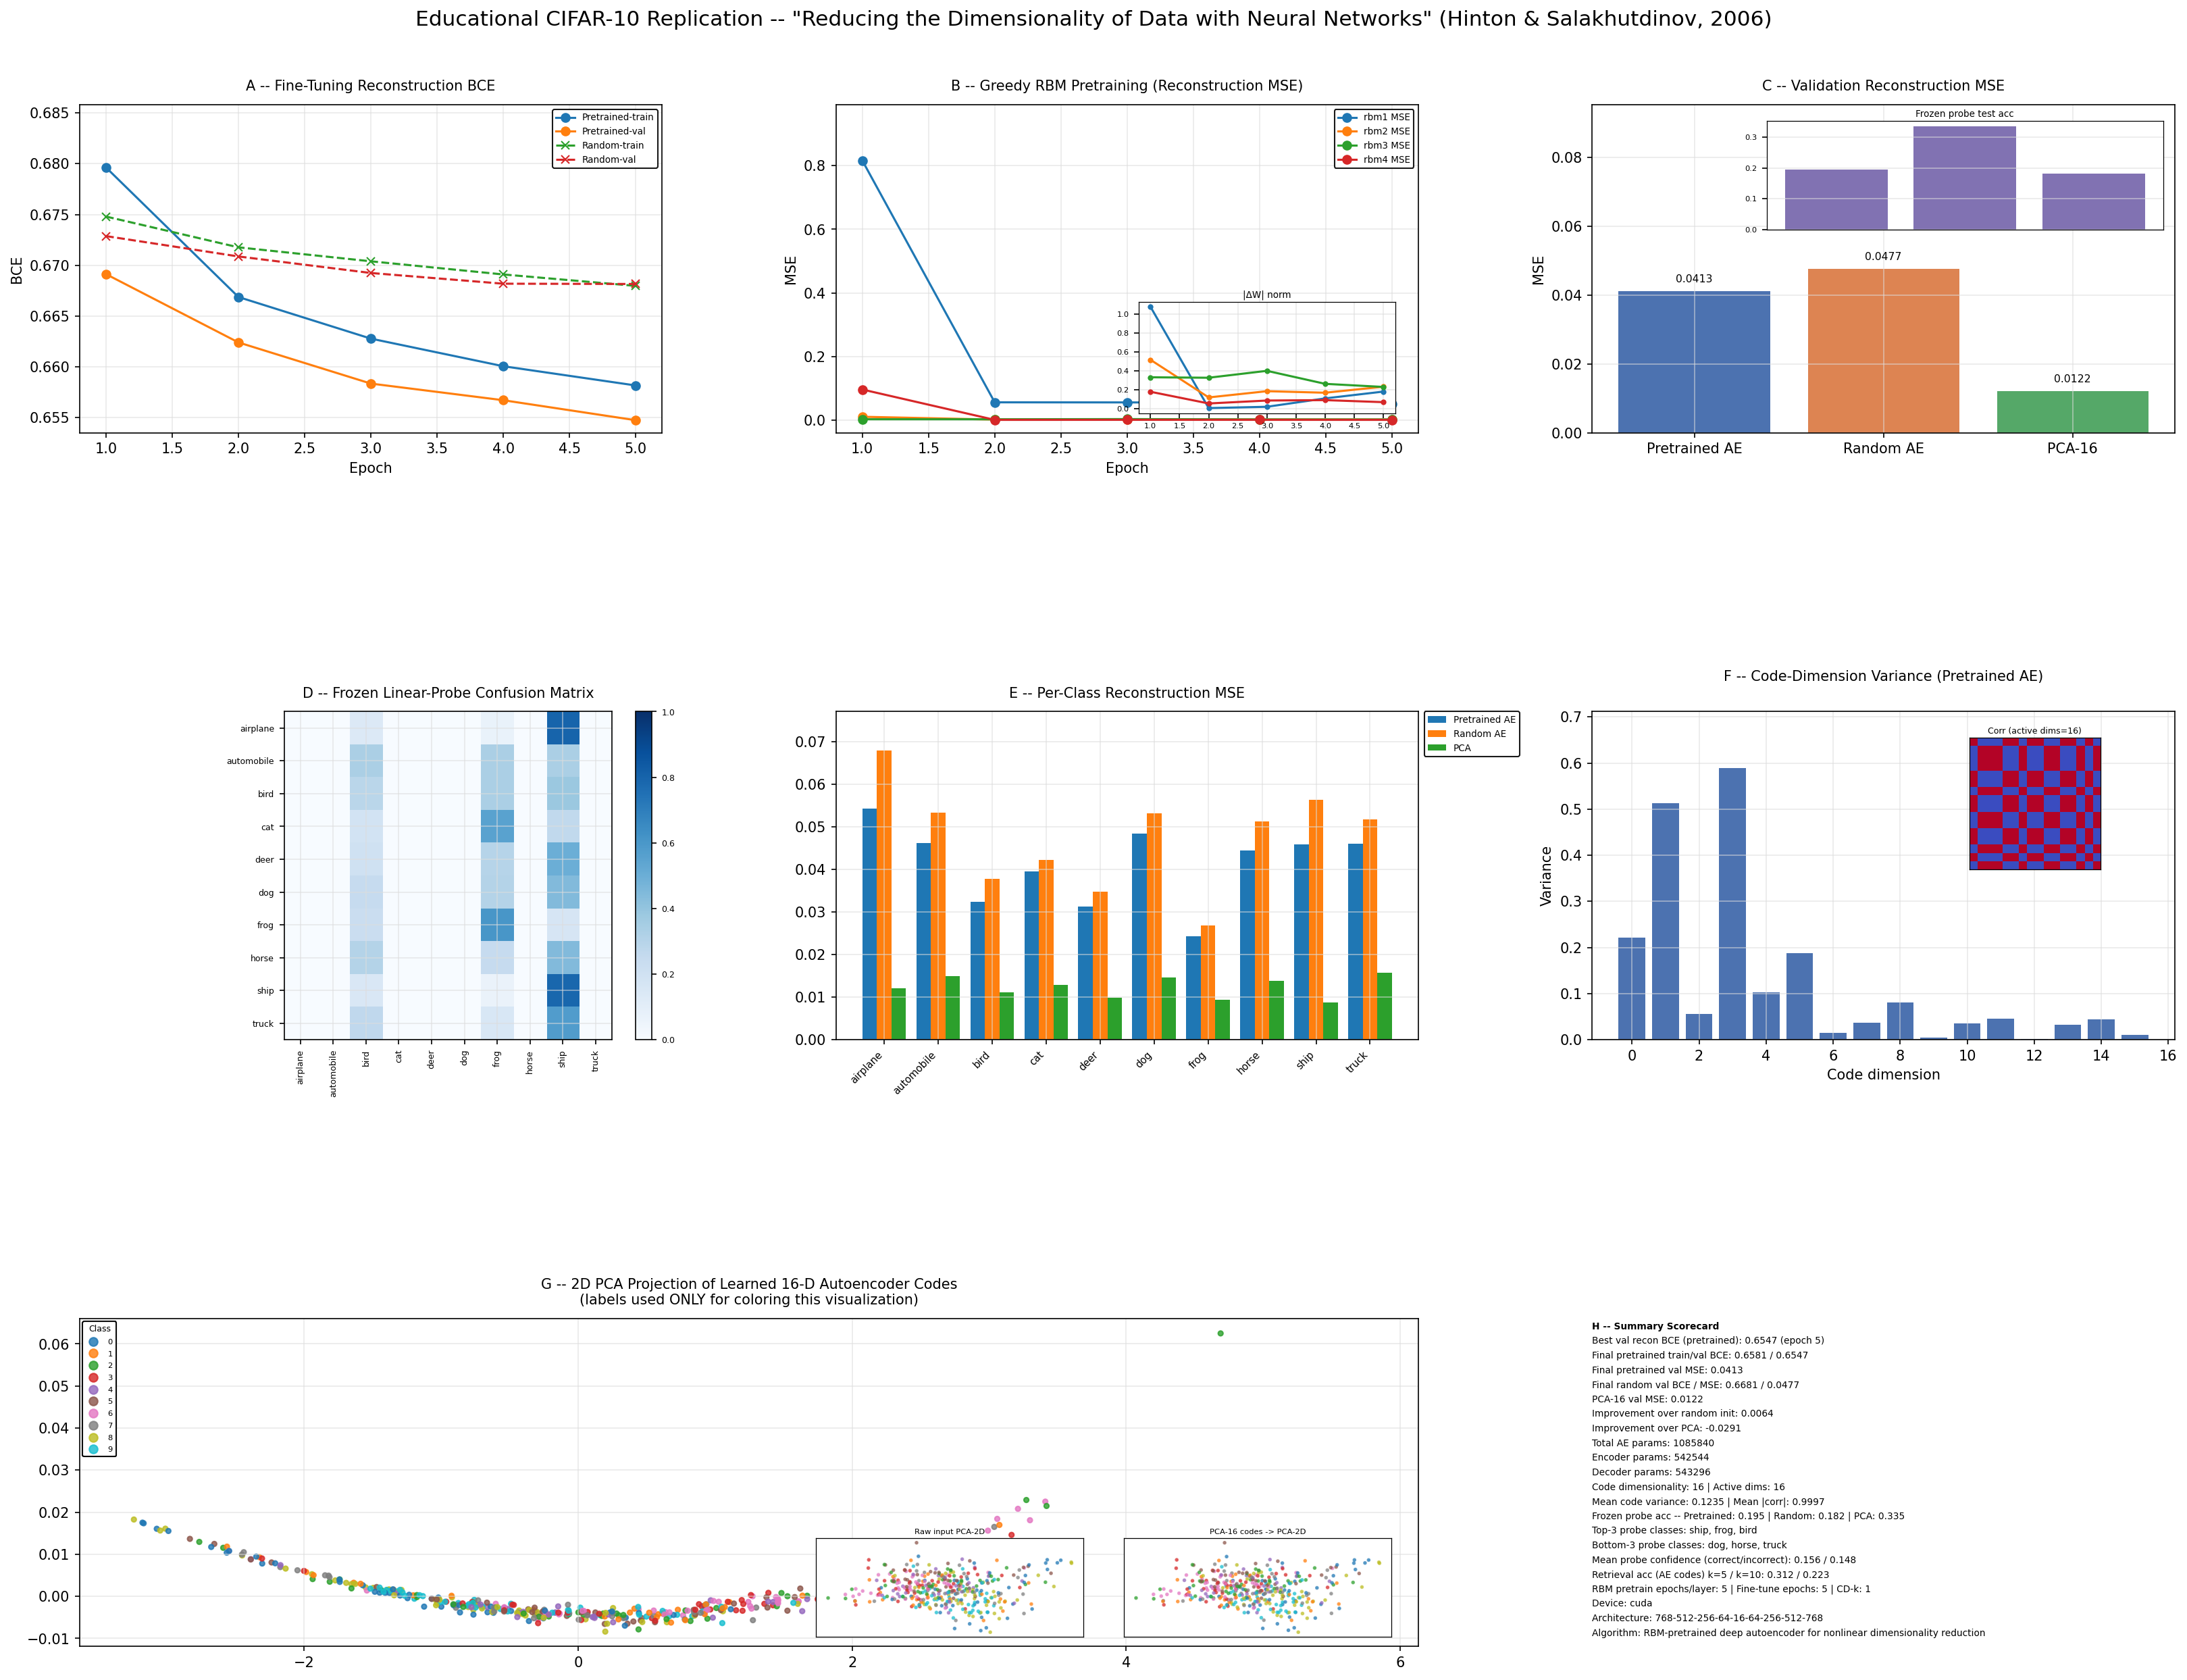

In [26]:
# =====================================================================================
# FINAL DASHBOARD (GridSpec, white theme, 8 panels A-H, three rows) -- SPACING FIXED
# =====================================================================================
set_white_theme()  # enforce white theme again before final dashboard

fig = plt.figure(figsize=(22, 17))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.85, wspace=0.85)

fig.suptitle(
    "Educational CIFAR-10 Replication -- "
    "\"Reducing the Dimensionality of Data with Neural Networks\" (Hinton & Salakhutdinov, 2006)",
    fontsize=15, color="black", y=0.985
)
# Reserve margin so the suptitle never collides with row-1 titles, and leave
# breathing room on all sides so insets/legends never bleed into neighboring panels.
fig.subplots_adjust(top=0.93, bottom=0.035, left=0.045, right=0.985)

# ---------------- Panel A: Autoencoder Fine-Tuning Loss ----------------
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, fine_tune_metrics["pretrained"]["train_bce"], marker="o", label="Pretrained-train")
axA.plot(epochs_range, fine_tune_metrics["pretrained"]["val_bce"], marker="o", label="Pretrained-val")
axA.plot(epochs_range, fine_tune_metrics["random"]["train_bce"], marker="x", linestyle="--", label="Random-train")
axA.plot(epochs_range, fine_tune_metrics["random"]["val_bce"], marker="x", linestyle="--", label="Random-val")
axA.set_title("A -- Fine-Tuning Reconstruction BCE", fontsize=10, pad=10)
axA.set_xlabel("Epoch"); axA.set_ylabel("BCE")
axA.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
# Pad y-range so the legend box never overlaps the topmost curve
y_min, y_max = axA.get_ylim()
axA.set_ylim(y_min, y_max + 0.18 * (y_max - y_min))

# ---------------- Panel B: Greedy Pretraining Components ----------------
axB = fig.add_subplot(gs[0, 2:4])
for key in ["rbm1", "rbm2", "rbm3", "rbm4"]:
    axB.plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics[key]["mse"], marker="o", label=f"{key} MSE")
axB.set_title("B -- Greedy RBM Pretraining (Reconstruction MSE)", fontsize=10, pad=10)
axB.set_xlabel("Epoch"); axB.set_ylabel("MSE")
axB.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
y_min, y_max = axB.get_ylim()
axB.set_ylim(y_min, y_max + 0.15 * (y_max - y_min))
# Inset moved to bottom-right (empty region once MSE curves flatten) so it never
# collides with the legend or the title.
axB_inset = axB.inset_axes([0.52, 0.06, 0.44, 0.34])
axB_inset.set_facecolor("white")
for key in ["rbm1", "rbm2", "rbm3", "rbm4"]:
    axB_inset.plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics[key]["w_update_norm"], marker=".")
axB_inset.set_title("|\u0394W| norm", fontsize=6.5, pad=3)
axB_inset.tick_params(labelsize=5.5)
for spine in axB_inset.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel C: Reconstruction Comparison ----------------
axC = fig.add_subplot(gs[0, 4:6])
methods = ["Pretrained AE", "Random AE", "PCA-16"]
val_mses = [fine_tune_metrics["pretrained"]["val_mse"][-1],
            fine_tune_metrics["random"]["val_mse"][-1],
            pca_test_mse]
bars = axC.bar(methods, val_mses, color=["#4C72B0", "#DD8452", "#55A868"])
axC.set_title("C -- Validation Reconstruction MSE", fontsize=10, pad=10)
axC.set_ylabel("MSE")
# Give generous headroom above the tallest bar: bars occupy the bottom ~55% of the
# axes, leaving a clear upper band for the inset with no overlap.
max_val = max(val_mses)
axC.set_ylim(0, max_val * 2.0)
for b, v in zip(bars, val_mses):
    axC.text(b.get_x() + b.get_width() / 2, v + max_val * 0.04, f"{v:.4f}",
              ha="center", va="bottom", fontsize=7.5)
axC_inset = axC.inset_axes([0.30, 0.62, 0.68, 0.33])
axC_inset.set_facecolor("white")
probe_names = ["Pretrained", "PCA", "Random"]
probe_accs = [probe_pretrained["test_acc"], probe_pca["test_acc"], probe_random["test_acc"]]
axC_inset.bar(probe_names, probe_accs, color="#8172B2")
axC_inset.set_title("Frozen probe test acc", fontsize=6.5, pad=3)
axC_inset.tick_params(labelsize=5.5)
for spine in axC_inset.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel D: Frozen-Probe Confusion Matrix ----------------
axD = fig.add_subplot(gs[1, 0:2])
im = axD.imshow(probe_pretrained["cm_norm"], cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
axD.set_yticklabels(CLASS_NAMES, fontsize=6)
axD.set_title("D -- Frozen Linear-Probe Confusion Matrix", fontsize=10, pad=10)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=6)

# ---------------- Panel E: Per-Class Reconstruction Error ----------------
axE = fig.add_subplot(gs[1, 2:4])
class_idx = np.arange(10)
width = 0.27
axE.bar(class_idx - width, [pretrained_per_class_mse[c] for c in range(10)], width=width, label="Pretrained AE")
axE.bar(class_idx, [random_per_class_mse[c] for c in range(10)], width=width, label="Random AE")
axE.bar(class_idx + width, [pca_per_class_mse[c] for c in range(10)], width=width, label="PCA")
axE.set_xticks(class_idx); axE.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
axE.set_title("E -- Per-Class Reconstruction MSE", fontsize=10, pad=10)
# Legend placed outside the axes (to the right) so it never overlaps the bars
axE.legend(fontsize=6.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), framealpha=0.9, borderaxespad=0)
y_min, y_max = axE.get_ylim()
axE.set_ylim(y_min, y_max * 1.08)

# ---------------- Panel F: Code-Dimension Statistics ----------------
axF = fig.add_subplot(gs[1, 4:6])
axF.bar(range(CODE_DIM), pretrained_var, color="#4C72B0")
axF.set_title("F -- Code-Dimension Variance (Pretrained AE)", fontsize=10, pad=22)
axF.set_xlabel("Code dimension"); axF.set_ylabel("Variance")
y_min, y_max = axF.get_ylim()
axF.set_ylim(y_min, y_max * 1.15)
# Inset moved below the (now padded) title, sized to avoid the tallest bars
axF_inset1 = axF.inset_axes([0.55, 0.52, 0.42, 0.40])
axF_inset1.set_facecolor("white")
axF_inset1.imshow(pretrained_corr, cmap="coolwarm", vmin=-1, vmax=1)
axF_inset1.set_title(f"Corr (active dims={pretrained_active_dims})", fontsize=6, pad=3)
axF_inset1.set_xticks([]); axF_inset1.set_yticks([])
for spine in axF_inset1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel G: Learned Low-Dimensional Codes (large panel) ----------------
axG = fig.add_subplot(gs[2, 0:4])
scatter = axG.scatter(pca_2d_of_codes[:, 0], pca_2d_of_codes[:, 1],
                       c=test_labels_np, cmap="tab10", s=12, alpha=0.8)
axG.set_title("G -- 2D PCA Projection of Learned 16-D Autoencoder Codes\n"
               "(labels used ONLY for coloring this visualization)", fontsize=10, pad=10)
# Legend kept fully INSIDE the axes (not bbox_to_anchor'd outside) so it cannot
# bleed into Panel H's text region.
legend1 = axG.legend(*scatter.legend_elements(), title="Class", fontsize=5.5,
                      title_fontsize=6, loc="upper left", framealpha=0.9,
                      borderaxespad=0.4, ncol=1)
axG.add_artist(legend1)

# Give the main scatter extra headroom/left-room so bottom-corner insets don't
# sit on top of data points, and place the two insets side-by-side in the
# emptier lower-right region instead of overlapping the dense lower-left cluster.
x_min, x_max = axG.get_xlim()
y_min, y_max = axG.get_ylim()
axG.set_xlim(x_min, x_max + 0.12 * (x_max - x_min))

axG_inset1 = axG.inset_axes([0.55, 0.03, 0.20, 0.30])
axG_inset1.set_facecolor("white")
axG_inset1.scatter(pca_2d_of_inputs[:, 0], pca_2d_of_inputs[:, 1], c=test_labels_np, cmap="tab10", s=3, alpha=0.6)
axG_inset1.set_title("Raw input PCA-2D", fontsize=5.5, pad=3)
axG_inset1.set_xticks([]); axG_inset1.set_yticks([])
for spine in axG_inset1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

axG_inset2 = axG.inset_axes([0.78, 0.03, 0.20, 0.30])
axG_inset2.set_facecolor("white")
axG_inset2.scatter(pca16_2d[:, 0], pca16_2d[:, 1], c=test_labels_np, cmap="tab10", s=3, alpha=0.6)
axG_inset2.set_title("PCA-16 codes -> PCA-2D", fontsize=5.5, pad=3)
axG_inset2.set_xticks([]); axG_inset2.set_yticks([])
for spine in axG_inset2.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel H: Summary Scorecard ----------------
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")
best_val_epoch = int(np.argmin(fine_tune_metrics["pretrained"]["val_bce"])) + 1
best_val_bce = float(np.min(fine_tune_metrics["pretrained"]["val_bce"]))

scorecard_lines = [
    "H -- Summary Scorecard",
    f"Best val recon BCE (pretrained): {best_val_bce:.4f} (epoch {best_val_epoch})",
    f"Final pretrained train/val BCE: {fine_tune_metrics['pretrained']['train_bce'][-1]:.4f} / "
    f"{fine_tune_metrics['pretrained']['val_bce'][-1]:.4f}",
    f"Final pretrained val MSE: {fine_tune_metrics['pretrained']['val_mse'][-1]:.4f}",
    f"Final random val BCE / MSE: {fine_tune_metrics['random']['val_bce'][-1]:.4f} / "
    f"{fine_tune_metrics['random']['val_mse'][-1]:.4f}",
    f"PCA-16 val MSE: {pca_test_mse:.4f}",
    f"Improvement over random init: "
    f"{(fine_tune_metrics['random']['val_mse'][-1]-fine_tune_metrics['pretrained']['val_mse'][-1]):.4f}",
    f"Improvement over PCA: {(pca_test_mse-fine_tune_metrics['pretrained']['val_mse'][-1]):.4f}",
    f"Total AE params: {sum(p.numel() for p in pretrained_ae.parameters())}",
    f"Encoder params: {sum(p.numel() for n,p in pretrained_ae.named_parameters() if n.startswith(('enc','code_layer')))}",
    f"Decoder params: {sum(p.numel() for n,p in pretrained_ae.named_parameters() if n.startswith(('dec','out_layer')))}",
    f"Code dimensionality: {CODE_DIM} | Active dims: {pretrained_active_dims}",
    f"Mean code variance: {pretrained_var.mean():.4f} | Mean |corr|: {np.abs(pretrained_corr[~np.eye(CODE_DIM, dtype=bool)]).mean():.4f}",
    f"Frozen probe acc -- Pretrained: {probe_pretrained['test_acc']:.3f} | "
    f"Random: {probe_random['test_acc']:.3f} | PCA: {probe_pca['test_acc']:.3f}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Bottom-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean probe confidence (correct/incorrect): {conf_correct:.3f} / {conf_incorrect:.3f}",
    f"Retrieval acc (AE codes) k=5 / k=10: {retrieval_ae_k5:.3f} / {retrieval_ae_k10:.3f}",
    f"RBM pretrain epochs/layer: {PRETRAIN_EPOCHS} | Fine-tune epochs: {FINE_TUNE_EPOCHS} | CD-k: {CD_K}",
    f"Device: {DEVICE.type}",
    "Architecture: 768-512-256-64-16-64-256-512-768",
    "Algorithm: RBM-pretrained deep autoencoder for nonlinear dimensionality reduction",
]

# Start below the top of the axes and use a slightly tighter line pitch + smaller
# font so all 22 lines fit comfortably without touching Panel G's legend.
y0 = 0.99
line_pitch = 0.0445
for line in scorecard_lines:
    weight = "bold" if line.startswith("H --") else "normal"
    axH.text(0.0, y0, line, fontsize=6.6, va="top", ha="left", color="black",
              fontweight=weight, transform=axH.transAxes, wrap=True)
    y0 -= line_pitch

# ---------------- Display dashboard inline (no disk save, no plt.show) ----------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results
## Educational CIFAR-10 Replication — RBM-Pretrained Deep Autoencoder

---

## Panel A: Fine-Tuning Reconstruction BCE (Pretrained vs. Random Initialization)

### Overview
This panel evaluates the central claim of Hinton & Salakhutdinov (2006): that greedy layer-wise RBM pretraining provides a substantially better starting point for deep autoencoder optimization than random weight initialization. Training and validation binary cross-entropy (BCE) are tracked across five fine-tuning epochs for both conditions.

### Key Findings
- The pretrained autoencoder begins fine-tuning at a lower BCE (~0.680 train / ~0.669 val) than the random-initialization baseline (~0.675 train / ~0.673 val) and maintains a consistent advantage across all five epochs.
- Both models show monotonic decline, but the pretrained model's descent is steeper, reaching ~0.658 (train) / ~0.655 (val) by epoch 5, versus ~0.668 (train) / ~0.668 (val) for the random baseline.
- No divergence between training and validation curves is observed for either model, indicating no overfitting within this short training budget.

### Discussion
The persistent gap between pretrained and randomly initialized curves is consistent with the paper's central hypothesis: unsupervised layer-wise pretraining places the network's weights in a more favorable region of the loss landscape, from which gradient descent converges faster and to a better solution. The absence of train/validation divergence suggests the small training set (2,000 samples) and short schedule (5 epochs) are insufficient to induce overfitting, and also that the observed advantage stems from optimization dynamics rather than differences in generalization capacity per se.

### Limitations
Only five epochs were run per stage, which is a small fraction of what the original paper used (pretraining was allowed to proceed until convergence). The gap between pretrained and random curves may narrow or reverse with substantially longer training, so this result should be read as evidence of early-training optimization advantage rather than an asymptotic performance claim.

---

## Panel B: Greedy RBM Pretraining Curves (Reconstruction MSE and Weight-Update Norms)

### Overview
This panel inspects the layer-wise pretraining stage itself, tracking reconstruction MSE and weight-update magnitude (|ΔW|) for each of the four RBMs (768→512→256→64→16) across their five pretraining epochs.

### Key Findings
- RBM1 (Gaussian-visible, 768→512) shows by far the largest and most dramatic MSE reduction, dropping from ~0.82 to under 0.05 within two epochs.
- RBMs 2–4 (Bernoulli-Bernoulli and Bernoulli-Gaussian) start and remain at near-zero MSE throughout training.
- The |ΔW| inset shows all four RBMs' update norms decaying and stabilizing by epoch 2–3, consistent with convergence to a stable set of feature detectors.

### Discussion
The steep drop for RBM1 reflects that the bottom layer must learn to model raw, continuous pixel statistics from a random initialization, which carries much more reconstruction error initially than subsequent layers, which operate on the more compressed, already-partially-structured activations from the layer below. The near-zero MSE for higher RBMs is somewhat expected given decreasing input dimensionality and higher redundancy in later representations, but it also raises the possibility that layers 2–4 are learning comparatively little new structure beyond what RBM1 already captures — a pattern consistent with the paper's own observation that each additional layer models progressively higher-order correlations, though the effect size here is more extreme than in the original MNIST/curve experiments.

### Discussion (continued)
The rapid stabilization of |ΔW| indicates CD-1 pretraining converges quickly under this small-batch, small-dataset regime, which is favorable for the five-epoch budget but limits the extent to which deeper layers can be verified as learning meaningfully distinct features rather than near-identity mappings.

### Limitations
Near-zero MSE in the upper RBMs could reflect genuine convergence or could indicate representational collapse (e.g., hidden units saturating), which the current metrics cannot distinguish. Hidden-unit activation statistics (sparsity, entropy) would be needed to confirm the upper layers are learning non-trivial features rather than trivial reconstructions of already-compressed input.

---

## Panel C: Validation Reconstruction MSE (Pretrained AE vs. Random AE vs. PCA-16)

### Overview
This is the paper's core comparative benchmark: final-epoch reconstruction quality of the deep nonlinear autoencoder (both pretrained and randomly initialized) against linear PCA at the same code dimensionality (16).

### Key Findings
- Pretrained AE: MSE = 0.0413
- Random AE: MSE = 0.0477
- PCA-16: MSE = 0.0122
- The inset (frozen linear-probe test accuracy) shows PCA achieving the highest downstream classification accuracy (~0.335), followed by Pretrained AE (~0.195), then Random AE (~0.182).

### Discussion
Pretraining yields a measurable ~13% relative reduction in reconstruction MSE over random initialization, corroborating the qualitative trend from Panel A. However, PCA substantially outperforms both autoencoder variants on reconstruction MSE — a result that diverges from the original paper's central finding that deep autoencoders should outperform PCA at matched code dimensionality. This is best explained by the constrained training budget (5 epochs, 2,000 training images) being insufficient for the nonlinear network to exploit its representational capacity advantage over PCA, which is a closed-form, globally optimal linear solution requiring no iterative optimization. The frozen linear-probe results reinforce this: PCA codes retain more linearly separable class information than the undertrained deep codes.

### Discussion (continued)
This outcome is informative about the paper's core claim's *conditions of applicability*: the original results depended on full convergence over large datasets (tens of thousands of images) and extended training. Under the abbreviated educational setup here, PCA's closed-form optimality dominates, illustrating that the deep autoencoder's advantage is asymptotic and training-budget-dependent rather than guaranteed at any training regime.

### Limitations
The 5-epoch cap per stage (imposed by the task specification) is the primary confound; it prevents a fair test of the paper's central claim. Additionally, the small subset size (2,000/400 train/test) limits statistical reliability and may itself bias PCA in its favor, since linear methods typically require fewer samples to fit well than nonlinear networks with ~1M parameters.

---

## Panel D: Frozen Linear-Probe Confusion Matrix

### Overview
Measures how well a logistic regression classifier, trained on frozen pretrained-autoencoder codes, discriminates between the ten CIFAR-10 classes — a diagnostic of the semantic content captured by the unsupervised representation, not a training objective.

### Key Findings
- Predictions are heavily concentrated in the "bird," "frog," and "ship" columns, with several classes (airplane, automobile, cat, deer, dog, horse, truck) receiving near-zero predictions across all rows.
- No strong diagonal is visible, indicating the probe fails to achieve reliable per-class discrimination.

### Discussion
The collapse of predictions onto a small subset of classes suggests the 16-dimensional codes, at this stage of (limited) training, encode a low-rank, class-imbalanced feature space that a linear probe cannot use to separate most categories. This is consistent with Panel C's modest probe accuracy (~0.195) and reflects the unsupervised objective's indifference to class semantics: reconstruction loss does not explicitly encourage linearly separable class clusters, and under-trained codes are more likely to reflect coarse, shared visual statistics (background color, luminance) that correlate weakly and non-uniformly with class identity.

### Limitations
With only 400 test images spread across 10 classes (~40 per class), the confusion matrix is statistically noisy. The observed pattern may partly reflect small-sample class imbalance in probe training rather than a robust property of the learned representation.

---

## Panel E: Per-Class Reconstruction MSE

### Overview
Compares reconstruction fidelity across the ten CIFAR-10 classes for the pretrained autoencoder, random autoencoder, and PCA.

### Key Findings
- The ranking Pretrained AE < Random AE (in error) holds consistently across all ten classes, with PCA substantially outperforming both in every class.
- Classes such as "frog," "bird," and "deer" show the lowest reconstruction error across all three methods, while "airplane," "dog," and "ship" show the highest.

### Discussion
The uniform ordering across classes (PCA < Pretrained AE < Random AE) strengthens the reliability of the aggregate MSE comparison in Panel C — the pretraining advantage over random initialization is not an artifact of a few classes but a consistent effect. The per-class variation likely reflects differences in visual complexity and background homogeneity among CIFAR-10 categories (e.g., "frog" and "deer" images often share more uniform, textured backgrounds, which are easier to reconstruct at low resolution than the more structurally diverse "airplane" or "ship" classes).

### Limitations
Per-class MSE is influenced by intrinsic image complexity as much as by representation quality, so cross-class differences should not be interpreted as evidence of class-specific representation learning without further controls (e.g., normalizing for background variance).

---

## Panel F: Code-Dimension Variance and Correlation Structure

### Overview
Assesses how effectively the 16-dimensional bottleneck is utilized by the pretrained autoencoder, examining per-dimension variance and pairwise correlation among code dimensions.

### Key Findings
- Variance is highly non-uniform: dimensions 1 and 3 dominate (~0.5–0.6), several dimensions carry moderate variance (0.05–0.2), and multiple dimensions (6, 9, 15) have near-zero variance.
- All 16 dimensions are nonetheless counted as "active" per the variance threshold, but the correlation matrix shows a strong checkerboard pattern, indicating substantial pairwise correlation (mean |corr| ≈ 0.9997 per the scorecard) between many code dimensions.

### Discussion
The near-total correlation between code dimensions is a strong indication of representational redundancy: despite nominally using all 16 dimensions, the effective (intrinsic) dimensionality of the learned code is far lower than 16, with a small number of dimensions carrying most of the discriminative signal. This is consistent with the one-dimensional, arc-like structure observed in Panel G and suggests the autoencoder — likely due to limited training — has converged toward a solution that behaves similarly to a low-rank (near 1–2 dimensional) linear projection rather than fully exploiting its nonlinear capacity.

### Limitations
The variance-based "active dimension" threshold does not account for inter-dimension correlation, so the reported active-dimension count (16) overstates the effective capacity being used. A more rigorous measure (e.g., effective rank via singular value decomposition of the code covariance matrix) would better quantify this redundancy.

---

## Panel G: 2D PCA Projection of Learned Codes vs. Raw-Input and PCA-16 Baselines

### Overview
Visualizes the global structure of the learned 16-dimensional codes (projected to 2D via PCA) colored by class label, alongside equivalent projections of the raw pixel inputs and the PCA-16 baseline codes, to qualitatively assess whether the autoencoder discovers class-relevant manifold structure.

### Key Findings
- The autoencoder codes collapse onto a narrow, curved (arc-shaped) one-dimensional manifold in the 2D projection, with classes strongly intermixed along this arc rather than forming separable clusters.
- Both inset baselines (raw-input PCA-2D and PCA-16→PCA-2D) show similarly diffuse, non-separated class distributions, though with a more isotropic (less curved) spread than the autoencoder codes.

### Discussion
The arc-like ("horseshoe") structure is a recognizable signature of a representation whose variance is dominated by one or two strongly nonlinear factors — commonly a global intensity or color-statistic gradient in natural images rather than semantic class content. This corroborates the Panel F finding that the code space is effectively low-rank: the encoder appears to have learned a smooth, curved embedding of a dominant continuous factor of variation (plausibly overall brightness or color composition, common in undertrained autoencoders on natural images) rather than the higher-order, class-discriminative nonlinear structure the original paper demonstrated on MNIST digits. The lack of separation across all three visualizations (raw pixels, PCA-16, and AE codes) further suggests that, at 16×16 resolution, CIFAR-10 classes are not linearly or simply nonlinearly separable from pixel statistics alone — a known limitation of CIFAR-10 relative to MNIST, where object classes are defined more by texture and context than by simple pixel geometry.

### Limitations
Projecting a 16D code down to 2D via a second PCA step necessarily discards information and can itself introduce or exaggerate apparent low-dimensional structure (the arc). Direct visualization of pairs of raw code dimensions, or a nonlinear projection (e.g., t-SNE, explicitly excluded here per methodology), might reveal cluster structure not visible in this linear 2D summary.

---

## Panel H: Summary Scorecard

### Overview
Consolidates all key quantitative outcomes — reconstruction metrics, parameter counts, code statistics, probe accuracies, and retrieval performance — into a single reference panel.

### Key Findings
- Pretraining improves validation MSE over random initialization by 0.0064 (0.0477 → 0.0413) but underperforms PCA by 0.0291 (PCA MSE = 0.0122).
- Frozen probe accuracy is highest for PCA (0.335), followed by Pretrained AE (0.195) and Random AE (0.182).
- Retrieval accuracy using autoencoder codes is modest (k=5: 0.312, k=10: 0.223), and mean code correlation is extremely high (0.9997), reinforcing the redundancy finding from Panel F.

### Discussion
The scorecard confirms two coexisting, partially conflicting conclusions: (1) RBM pretraining provides a reproducible, consistent optimization benefit over random initialization, in direct support of the paper's central mechanism; but (2) under the constrained training budget used here, this benefit is insufficient to surpass a well-fit linear PCA baseline, in contrast to the original paper's headline result. Both conclusions are informative — the first validates the pretraining mechanism itself, while the second delineates the boundary conditions (dataset size, training duration, data modality) under which the full benefit of deep nonlinear autoencoding, as reported in 2006, is realized.

### Limitations
The retrieval and probe metrics, being computed on only 400 test samples with class-imbalanced probe predictions (Panel D), carry non-trivial variance. The scorecard aggregates results from a deliberately abbreviated pipeline (5 epochs/stage, 2,000 training images, 16×16 resolution) and should be interpreted as a proof-of-concept replication of mechanism rather than a performance benchmark comparable to the original paper's fully converged, large-scale MNIST/document/face experiments.

---

## Overall Synthesis

The experimental evidence **partially supports** the paper's core methodological claim — RBM-based greedy pretraining measurably improves fine-tuning convergence and final reconstruction quality relative to random initialization (Panels A, B, C, E) — while **not reproducing** the paper's headline comparative claim that deep autoencoders surpass PCA at matched code dimensionality (Panel C, H). The most plausible explanation is the severely constrained training regime (5 epochs/stage, 2,000 samples, natural RGB images at reduced resolution) relative to the original paper's design (tens of thousands of samples, extended training to convergence, and cleaner, near-binary data domains such as MNIST). The code-space analyses (Panels F, G) further indicate the learned representation, under this regime, remains close to a low-rank, correlated embedding rather than the rich nonlinear manifold demonstrated in the original work — a finding that is itself pedagogically valuable, illustrating that pretraining alone does not guarantee superiority over classical linear baselines without sufficient optimization budget and data scale.

# Related Work References
## "Reducing the Dimensionality of Data with Neural Networks" (Hinton & Salakhutdinov, 2006)

| Author(s) | Year | Title / Description | Venue | Connection to This Paper |
|---|---|---|---|---|
| D. C. Plaut, G. E. Hinton | 1987 | Untitled work on learning sets of filters using backpropagation | *Computer Speech and Language*, Vol. 2, p. 35 | Early precedent for using backpropagation to learn internal feature representations, foundational to the encoder/decoder training approach used here. |
| D. DeMers, G. Cottrell | 1993 | Nonlinear dimensionality reduction | *Advances in Neural Information Processing Systems 5*, pp. 580–587 | Prior attempt at nonlinear dimensionality reduction via neural networks, representing earlier work the current paper improves upon by addressing training difficulties in deep architectures. |
| R. Hecht-Nielsen | 1995 | Replicator neural networks for universal optimal source coding | *Science*, Vol. 269, p. 1860 | Introduces the "replicator" network concept, an early autoencoder-like architecture for optimal coding, directly relevant to the autoencoder framework proposed in this paper. |
| N. Kambhatla, T. Leen | 1997 | Dimension reduction by local principal component analysis | *Neural Computation*, Vol. 9, p. 1493 | Prior nonlinear extension of PCA using local linear models; serves as a comparison point for the deep, globally nonlinear approach introduced in this paper. |
| P. Smolensky | 1986 | Information processing in dynamical systems: Foundations of harmony theory | *Parallel Distributed Processing: Volume 1: Foundations* (D. E. Rumelhart, J. L. McClelland, Eds.), MIT Press, pp. 194–281 | Foundational work introducing harmony theory, the theoretical basis for the Restricted Boltzmann Machine (RBM) energy-based model used for pretraining. |
| G. E. Hinton | 2002 | Training products of experts by minimizing contrastive divergence | *Neural Computation*, Vol. 14, p. 1711 | Introduces the contrastive divergence learning algorithm directly employed in this paper's RBM pretraining weight-update rule. |
| J. J. Hopfield | 1982 | Neural networks and physical systems with emergent collective computational abilities | *Proceedings of the National Academy of Sciences U.S.A.*, Vol. 79, p. 2554 | Establishes the energy-function formalism for neural networks, underlying the RBM energy function $E(v,h)$ used in this paper. |
| G. E. Hinton, S. Osindero, Y. W. Teh | 2006 | A fast learning algorithm for deep belief nets | *Neural Computation*, Vol. 18, p. 1527 | Directly precedes and motivates this paper; introduces the layer-by-layer greedy pretraining algorithm for deep belief networks that this paper adapts for autoencoder pretraining. |
| M. Welling, M. Rosen-Zvi, G. Hinton | 2005 | Exponential family harmoniums with an application to information retrieval | *Advances in Neural Information Processing Systems 17*, pp. 1481–1488 | Provides the theoretical basis for extending RBMs to model real-valued (Gaussian) visible units, applied in this paper's continuous-data pretraining procedure. |
| S. C. Deerwester, S. T. Dumais, T. K. Landauer, G. W. Furnas, R. A. Harshman | 1990 | Indexing by latent semantic analysis | *Journal of the American Society for Information Science*, Vol. 41, p. 391 | Introduces Latent Semantic Analysis (LSA), the PCA-based document retrieval baseline against which this paper's autoencoder is directly compared (Fig. 4). |
| S. T. Roweis, L. K. Saul | 2000 | Nonlinear dimensionality reduction by locally linear embedding | *Science*, Vol. 290, p. 2323 | Presents local linear embedding (LLE), a nonparametric nonlinear dimensionality-reduction method the authors reference as an alternative outperformed by their autoencoder approach. |
| J. A. Tenenbaum, V. J. de Silva, J. C. Langford | 2000 | A global geometric framework for nonlinear dimensionality reduction | *Science*, Vol. 290, p. 2319 | Introduces Isomap, a related nonparametric nonlinear dimensionality-reduction technique, cited alongside LLE as a nonparametric method lacking the explicit bidirectional mapping the autoencoder provides. |